
---

# Part A — Step 7: first parametric family (wide box)

δ∈[0.4,0.8], γ∈[0.4,4.2], ω∈[1.3,2.6] — retrospectively 25% chaotic. Includes the Lyapunov-filtered ray diagram (7b).

---


# Duffing Neural ODE — Step 7: learning the whole family

Until now every model owned exactly one oscillator. This notebook feeds the physical
parameters to the network and learns the **map from $(x, \dot{x}, \text{phase},
\delta, \gamma, \omega)$ to acceleration** — one model for the entire Duffing family
over

$$\delta \in [0.4, 0.8], \qquad \gamma \in [0.4, 4.2], \qquad \omega \in [1.3, 2.6],$$

a box that contains every regime we studied in Steps 2–6 (single-well period-1,
big cross-well period-1, period-8, period-3 + coexisting chaos, and stretches of the
chaotic sea).

Two models, matched to the Step 5–6 finalists but with the new inputs:

| model | acceleration | inputs | params |
|---|---|---|---|
| **scalar** | one MLP, 1 output | $(x, \dot{x}, \cos\omega t, \sin\omega t, \delta, \gamma, \omega)$ flat | ~4.7k |
| **additive** | $f_\theta(x) + d_\theta(\dot{x}, \delta) + g_\theta(\cos\omega t, \sin\omega t, \gamma, \omega)$ | routed | ~3.6k |

The additive routing now encodes *parameter* physics on top of the force split:
$f$ takes **no parameters** (the restoring force is shared by the whole family — and
gets trained by every trajectory of every oscillator), $\delta$ can only touch the
damping term, and $\gamma, \omega$ can only touch the drive. Two claims the truth
satisfies ($f = x - x^3$ for everyone; $d = -\delta\dot{x}$; $g = \gamma\cos\omega t$)
and the black box has to discover on its own. One deliberate redundancy: $g$ receives
$\omega$ even though the phase pair already encodes it — whether $g$ *learns to ignore
$\omega$* becomes an evaluation.

Data: 48 Latin-hypercube parameter draws × 21 ICs each (7×3 grid auto-scaled to that
oscillator's own attractor extent) × 20 s → **~2M training pairs**. Evaluations focus
on the new dimension: held-out ICs at trained parameters, **unseen interior parameter
draws** (parameter interpolation), and **parameter-extrapolation rays** marching
$\delta$, $\gamma$, $\omega$ out of the training box.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

P_LO = np.array([0.4, 0.4, 1.3])   # delta, gamma, omega
P_HI = np.array([0.8, 4.2, 2.6])
N_SETS = 48
N_EVAL_SETS = 12

def true_rhs(s, t, ph):
    x, v = s
    delta, gamma, omega = ph
    return jnp.array([v, -delta * v + x - x**3 + gamma * jnp.cos(omega * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

DT_INT, DT_SAVE = 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))

def sim_true(s0, ph, n_save, substeps=SUBS):
    return simulate(lambda s, t: true_rhs(s, t, ph), jnp.asarray(s0), 0.0,
                    n_save, DT_SAVE, substeps)

def lhs_box(n, lo, hi, rng):
    out = np.empty((n, len(lo)))
    for j in range(len(lo)):
        out[:, j] = lo[j] + (hi[j] - lo[j]) * \
            (rng.permutation(n) + rng.uniform(size=n)) / n
    return out

rng = np.random.default_rng(42)
PARAM_SETS = lhs_box(N_SETS, P_LO, P_HI, rng)
print('48 training parameter sets (Latin hypercube), first 5:')
for ph in PARAM_SETS[:5]:
    print(f'   delta={ph[0]:.3f}  gamma={ph[1]:.3f}  omega={ph[2]:.3f}')

48 training parameter sets (Latin hypercube), first 5:
   delta=0.712  gamma=4.157  omega=1.645
   delta=0.652  gamma=0.891  omega=1.903
   delta=0.776  gamma=2.958  omega=1.325
   delta=0.687  gamma=1.633  omega=2.552
   delta=0.444  gamma=2.710  omega=1.953


## 1 — Training data: 48 oscillators × 21 ICs

For each parameter set: a 120 s pre-sim measures that oscillator's attractor extent,
the 7×3 IC grid is scaled to 80% of it, and 21 trajectories of 20 s are generated.
Chaotic parameter draws are welcome — one-step training only needs the vector field
sampled broadly, not tidy orbits.

In [2]:
T_PRE = 120.0
N_PRE = int(round(T_PRE / DT_SAVE))
pre = np.asarray(jax.vmap(
    lambda ph: sim_true(jnp.array([0.5, 0.0]), ph, N_PRE))(
        jnp.asarray(PARAM_SETS)))
tail = pre[:, int(40.0 / DT_SAVE):, :]
EXT = np.abs(tail).max(axis=1)           # (48, 2)
BOX = np.round(0.8 * EXT, 1)
print('attractor extent across the family:')
print(f'   |x|: min {EXT[:, 0].min():.2f}  max {EXT[:, 0].max():.2f}')
print(f'   |v|: min {EXT[:, 1].min():.2f}  max {EXT[:, 1].max():.2f}')

N_IC_X, N_IC_V = 7, 3
N_ICS = N_IC_X * N_IC_V
T_END = 20.0
N_SAVE = int(round(T_END / DT_SAVE))
times = np.arange(N_SAVE + 1) * DT_SAVE

ic_all, ph_all = [], []
for k in range(N_SETS):
    g = np.stack(np.meshgrid(np.linspace(-BOX[k, 0], BOX[k, 0], N_IC_X),
                             np.linspace(-BOX[k, 1], BOX[k, 1], N_IC_V),
                             indexing='ij'), axis=-1).reshape(-1, 2)
    ic_all.append(g)
    ph_all.append(np.repeat(PARAM_SETS[k][None], N_ICS, axis=0))
ic_all = np.concatenate(ic_all)          # (1008, 2)
ph_all = np.concatenate(ph_all)          # (1008, 3)

trajs = np.asarray(jax.vmap(lambda s0, ph: sim_true(s0, ph, N_SAVE))(
    jnp.asarray(ic_all), jnp.asarray(ph_all)))
print('training trajectories:', trajs.shape)

s_now = jnp.asarray(trajs[:, :-1, :].reshape(-1, 2))
s_next = jnp.asarray(trajs[:, 1:, :].reshape(-1, 2))
t_now = jnp.asarray(np.tile(times[:-1], len(ic_all)))
p_now = jnp.asarray(np.repeat(ph_all, N_SAVE, axis=0))
N_PAIRS = s_now.shape[0]
print(f'training pairs: {N_PAIRS:,}')

attractor extent across the family:
   |x|: min 0.91  max 2.76
   |v|: min 0.40  max 4.13


training trajectories: (1008, 2001, 2)
training pairs: 2,016,000


## 2 — The two models

In [3]:
def init_mlp(key, layers):
    params = []
    for n_in, n_out in zip(layers[:-1], layers[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def mlp(params, u):
    h = u
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

LAYERS_SCALAR = [7, 64, 64, 1]
def init_scalar(key):
    return init_mlp(key, LAYERS_SCALAR)
def rhs_scalar(params, s, t, ph):
    delta, gamma, omega = ph
    u = jnp.array([s[0], s[1], jnp.cos(omega * t), jnp.sin(omega * t),
                   delta, gamma, omega])
    return jnp.array([s[1], mlp(params, u)[0]])

F_LAYERS = [1, 32, 32, 1]
D_LAYERS = [2, 32, 32, 1]
G_LAYERS = [4, 32, 32, 1]
N_F, N_D = len(F_LAYERS) - 1, len(D_LAYERS) - 1

def init_additive(key):
    kf, kd, kg = jax.random.split(key, 3)
    return (init_mlp(kf, F_LAYERS) + init_mlp(kd, D_LAYERS)
            + init_mlp(kg, G_LAYERS))

def additive_terms(params, s, t, ph):
    delta, gamma, omega = ph
    pf = params[:N_F]
    pd = params[N_F:N_F + N_D]
    pg = params[N_F + N_D:]
    f = mlp(pf, jnp.array([s[0]]))[0]
    d = mlp(pd, jnp.array([s[1], delta]))[0]
    g = mlp(pg, jnp.array([jnp.cos(omega * t), jnp.sin(omega * t),
                           gamma, omega]))[0]
    return f, d, g

def rhs_additive(params, s, t, ph):
    f, d, g = additive_terms(params, s, t, ph)
    return jnp.array([s[1], f + d + g])

for name, init in [('scalar', init_scalar), ('additive', init_additive)]:
    n = sum(W.size + b.size for W, b in init(jax.random.PRNGKey(0)))
    print(f'{name:9s} parameters: {n}')

scalar    parameters: 4737


additive  parameters: 3587


## 3 — Training

Same one-step harness, scaled up: 30k Adam steps (lr 1e-3 → 1e-4 at 20k), batch
16,384 drawn from the 2M-pair pool. The tracked loss is on a fixed 131k-pair random
subset (evaluating all 2M every 500 steps would dominate the run). Caches
`params_family_<model>.npz` — delete to retrain.

In [4]:
import os

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

BATCH = 16384
N_STEPS = 30000
LR_DROP = 20000
EVAL_EVERY = 500
EVAL_IDX = jnp.asarray(np.random.default_rng(3).choice(N_PAIRS, 131072,
                                                       replace=False))

def train(rhs, init_fn, model_tag):
    def one_step(params, s, t, ph):
        return rk4_step(lambda s_, t_: rhs(params, s_, t_, ph), s, t, DT_SAVE)

    def loss_on(params, sb, snb, tb, pb):
        pred = jax.vmap(lambda s, t, ph: one_step(params, s, t, ph))(sb, tb, pb)
        return jnp.mean((pred - snb) ** 2)

    eval_loss = jax.jit(lambda p: loss_on(p, s_now[EVAL_IDX], s_next[EVAL_IDX],
                                          t_now[EVAL_IDX], p_now[EVAL_IDX]))

    cache = f'params_family_{model_tag}.npz'
    if os.path.exists(cache):
        z = np.load(cache)
        n_layers = sum(1 for k in z.files if k.startswith('W'))
        params = [(jnp.asarray(z[f'W{i}']), jnp.asarray(z[f'b{i}']))
                  for i in range(n_layers)]
        print(f'[{model_tag}] loaded cached params from {cache}   '
              f'eval loss {float(eval_loss(params)):.3e}   '
              f'(delete the file to retrain)')
        return (params, z['hist_steps'], z['hist_loss'], float(z['wall']))

    @jax.jit
    def train_step(params, m, v, step, lr, key):
        idx = jax.random.randint(key, (BATCH,), 0, N_PAIRS)
        loss, grads = jax.value_and_grad(loss_on)(
            params, s_now[idx], s_next[idx], t_now[idx], p_now[idx])
        params, m, v = adam_update(params, grads, m, v, step, lr)
        return params, m, v, loss

    params = init_fn(jax.random.PRNGKey(0))
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    base_key = jax.random.PRNGKey(1)

    hist_steps, hist_loss = [], []
    t0 = time.time()
    for i in range(1, N_STEPS + 1):
        lr = 1e-3 if i <= LR_DROP else 1e-4
        params, m, v, _ = train_step(params, m, v, float(i), lr,
                                     jax.random.fold_in(base_key, i))
        if i == 1 or i % EVAL_EVERY == 0:
            fl = float(eval_loss(params))
            hist_steps.append(i)
            hist_loss.append(fl)
            if i == 1 or i % 5000 == 0:
                print(f'[{model_tag}] step {i:6d}   lr {lr:.0e}'
                      f'   eval loss {fl:.3e}')
    wall = time.time() - t0
    print(f'[{model_tag}] final eval loss {hist_loss[-1]:.3e}'
          f'   wall time {wall:.0f} s')
    np.savez(cache, hist_steps=np.array(hist_steps),
             hist_loss=np.array(hist_loss), wall=wall,
             **{f'W{i}': np.asarray(Wt) for i, (Wt, _) in enumerate(params)},
             **{f'b{i}': np.asarray(bt) for i, (_, bt) in enumerate(params)})
    return params, np.array(hist_steps), np.array(hist_loss), wall

params_s, steps_s, loss_s, wall_s = train(rhs_scalar, init_scalar, 'scalar')
params_a, steps_a, loss_a, wall_a = train(rhs_additive, init_additive,
                                          'additive')

MODELS = [('scalar', rhs_scalar, params_s, 'tab:blue'),
          ('additive', rhs_additive, params_a, 'tab:green')]

[scalar] loaded cached params from params_family_scalar.npz   eval loss 6.734e-09   (delete the file to retrain)


[additive] loaded cached params from params_family_additive.npz   eval loss 3.886e-09   (delete the file to retrain)


## 4 — Learning curves

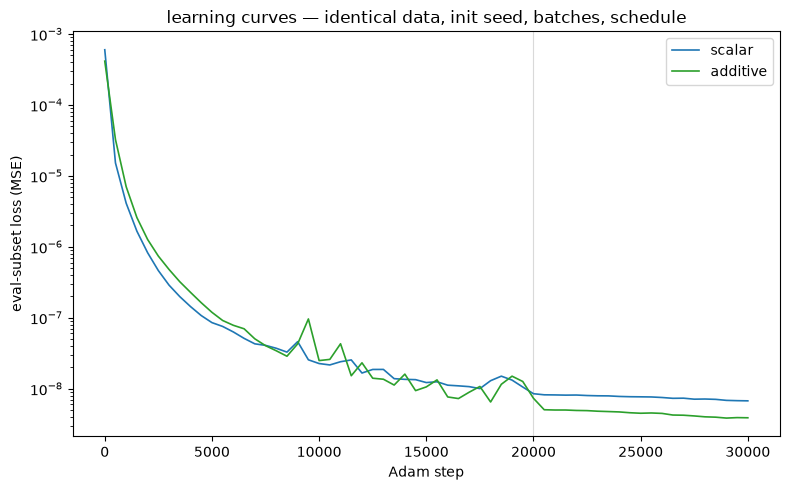

final loss   scalar 6.734e-09   additive 3.886e-09
wall time    scalar 347 s   additive 367 s


In [5]:
fig, a = plt.subplots(figsize=(8, 5))
for (tag, _, _, color), st, lo in [(MODELS[0], steps_s, loss_s),
                                   (MODELS[1], steps_a, loss_a)]:
    a.semilogy(st, lo, color=color, lw=1.2, label=tag)
a.axvline(LR_DROP, color='0.85', lw=0.8, zorder=0)
a.set_xlabel('Adam step')
a.set_ylabel('eval-subset loss (MSE)')
a.set_title('learning curves — identical data, init seed, batches, schedule')
a.legend()
plt.tight_layout(); plt.show()

print(f'final loss   scalar {loss_s[-1]:.3e}   additive {loss_a[-1]:.3e}')
print(f'wall time    scalar {wall_s:.0f} s   additive {wall_a:.0f} s')

## 5 — One-step errors and held-out ICs at trained parameters

One-step error over all 2M pairs (chunked), then 20 s rollouts from held-out interior
ICs at four of the 48 trained parameter sets — the easiest ask: same oscillators,
new starts.

In [6]:
def one_step_errors(rhs, params):
    f = jax.jit(jax.vmap(lambda s, t, ph: rk4_step(
        lambda s_, t_: rhs(params, s_, t_, ph), s, t, DT_SAVE)))
    errs = []
    CH = 262144
    for i in range(0, N_PAIRS, CH):
        pred = f(s_now[i:i + CH], t_now[i:i + CH], p_now[i:i + CH])
        errs.append(np.asarray(
            jnp.linalg.norm(pred - s_next[i:i + CH], axis=1)))
    return np.concatenate(errs)

for tag, rhs, p, _ in MODELS:
    e = one_step_errors(rhs, p)
    print(f'{tag:9s} one-step error   median {np.median(e):.2e}'
          f'   mean {e.mean():.2e}   max {e.max():.2e}')

LOCK_ERR = 1.0
lock_win = times[:-1] >= T_END - 5.0

def rollout_err(rhs, params, ic, ph):
    tru = np.asarray(sim_true(ic, jnp.asarray(ph), N_SAVE))
    rol = np.asarray(simulate(lambda s, t: rhs(params, s, t, jnp.asarray(ph)),
                              jnp.asarray(ic), 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    return err.mean(), err[:-1][lock_win].mean() < LOCK_ERR

FRACS = [(0.44, 0.42), (-0.81, -0.72), (0.93, 0.87)]
SHOW_SETS = [0, 13, 27, 41]
print()
print('held-out ICs at trained parameter sets (mean rollout error, 20 s):')
print(f'{"params (d, g, w)":>26s} {"IC":>15s} {"scalar":>11s} {"additive":>11s}'
      '   locked?')
for k in SHOW_SETS:
    ph = PARAM_SETS[k]
    for fx, fv in FRACS:
        ic = (round(fx * BOX[k, 0], 2), round(fv * BOX[k, 1], 2))
        row, locks = [], []
        for tag, rhs, p, _ in MODELS:
            e, l = rollout_err(rhs, p, jnp.array(ic), ph)
            row.append(e)
            locks.append(l)
        lab = f'({ph[0]:.2f}, {ph[1]:.2f}, {ph[2]:.2f})'
        print(f'{lab:>26s} {str(ic):>15s} {row[0]:>11.2e} {row[1]:>11.2e}'
              f'   {locks[0]} / {locks[1]}')

scalar    one-step error   median 5.95e-05   mean 7.99e-05   max 5.84e-03


additive  one-step error   median 4.02e-05   mean 5.34e-05   max 8.72e-03

held-out ICs at trained parameter sets (mean rollout error, 20 s):
          params (d, g, w)              IC      scalar    additive   locked?


        (0.71, 4.16, 1.65) (np.float64(0.92), np.float64(1.22))    7.71e-03    2.61e-03   True / True


        (0.71, 4.16, 1.65) (np.float64(-1.7), np.float64(-2.09))    7.38e-03    1.87e-02   True / True


        (0.71, 4.16, 1.65) (np.float64(1.95), np.float64(2.52))    4.43e-03    3.63e-03   True / True


...

        (0.66, 4.00, 1.54) (np.float64(-1.7), np.float64(-1.94))    1.96e-02    1.77e-02   True / True


        (0.66, 4.00, 1.54) (np.float64(1.95), np.float64(2.35))    4.65e-03    7.65e-03   True / True


        (0.79, 0.47, 1.87) (np.float64(0.4), np.float64(0.13))    4.02e-03    3.06e-03   True / True


        (0.79, 0.47, 1.87) (np.float64(-0.73), np.float64(-0.22))    3.97e-03    3.85e-03   True / True


        (0.79, 0.47, 1.87) (np.float64(0.84), np.float64(0.26))    3.97e-03    3.20e-03   True / True


## 6 — Parameter interpolation: 12 unseen parameter draws

The new dimension's core test. Twelve fresh Latin-hypercube draws from the *same box*
— oscillators the models have never seen — three held-out ICs each (scaled to each
oscillator's own measured extent). If the models learned the family and not 48
oscillators, these numbers should look like Section 5's.

In [7]:
EVAL_SETS = lhs_box(N_EVAL_SETS, P_LO, P_HI, np.random.default_rng(7))
pre_e = np.asarray(jax.vmap(
    lambda ph: sim_true(jnp.array([0.5, 0.0]), ph, N_PRE))(
        jnp.asarray(EVAL_SETS)))
EXT_E = np.abs(pre_e[:, int(40.0 / DT_SAVE):, :]).max(axis=1)

print('unseen interior parameter draws (mean rollout error, 20 s):')
print(f'{"params (d, g, w)":>26s} {"IC":>15s} {"scalar":>11s} {"additive":>11s}'
      '   locked?')
all_err = {tag: [] for tag, *_ in MODELS}
for k in range(N_EVAL_SETS):
    ph = EVAL_SETS[k]
    lims = 0.8 * EXT_E[k]
    for fx, fv in FRACS:
        ic = (round(fx * lims[0], 2), round(fv * lims[1], 2))
        row, locks = [], []
        for tag, rhs, p, _ in MODELS:
            e, l = rollout_err(rhs, p, jnp.array(ic), ph)
            row.append(e)
            locks.append(l)
            all_err[tag].append(e)
        lab = f'({ph[0]:.2f}, {ph[1]:.2f}, {ph[2]:.2f})'
        print(f'{lab:>26s} {str(ic):>15s} {row[0]:>11.2e} {row[1]:>11.2e}'
              f'   {locks[0]} / {locks[1]}')
print()
for tag, *_ in MODELS:
    e = np.array(all_err[tag])
    print(f'{tag:9s} over all 36 unseen-param rollouts:'
          f'   median {np.median(e):.2e}   mean {e.mean():.2e}'
          f'   max {e.max():.2e}')

unseen interior parameter draws (mean rollout error, 20 s):
          params (d, g, w)              IC      scalar    additive   locked?


        (0.56, 1.81, 1.74) (np.float64(0.61), np.float64(0.65))    5.75e-01    5.41e-01   False / False


        (0.56, 1.81, 1.74) (np.float64(-1.12), np.float64(-1.12))    4.99e-02    6.21e-01   True / False


        (0.56, 1.81, 1.74) (np.float64(1.28), np.float64(1.35))    3.90e-01    6.16e-01   False / False


        (0.63, 0.69, 1.68) (np.float64(0.46), np.float64(0.23))    5.58e-03    5.94e-03   True / True


...

        (0.73, 3.37, 1.93) (np.float64(-0.67), np.float64(-0.86))    7.59e-02    2.32e-02   True / True


        (0.73, 3.37, 1.93) (np.float64(0.77), np.float64(1.04))    8.13e-02    7.68e-03   True / True


        (0.79, 1.35, 2.32) (np.float64(0.45), np.float64(0.26))    6.78e-03    3.23e-03   True / True


        (0.79, 1.35, 2.32) (np.float64(-0.82), np.float64(-0.45))    7.52e-03    8.35e-03   True / True


        (0.79, 1.35, 2.32) (np.float64(0.94), np.float64(0.54))    6.08e-03    7.22e-03   True / True

scalar    over all 36 unseen-param rollouts:   median 2.02e-02   mean 1.01e-01   max 7.05e-01
additive  over all 36 unseen-param rollouts:   median 1.94e-02   mean 1.24e-01   max 6.21e-01


## 7 — Parameter-extrapolation rays

The parameter-space analog of the IC rays: fix the IC at $(0.5, 0)$ and march one
parameter through and past the training box (red dashed = box edges; rug ticks =
the 48 training values of that parameter). Held-out center values for the other two
parameters. Where does the family model stop being trustworthy in *parameter* space?

gamma  ray  scalar    median err 4.77e-02   lost-lock: 0/61


gamma  ray  additive  median err 4.80e-02   lost-lock: 2/61


delta  ray  scalar    median err 9.03e-02   lost-lock: 12/61


delta  ray  additive  median err 2.84e-01   lost-lock: 23/61


omega  ray  scalar    median err 2.96e-02   lost-lock: 3/61


omega  ray  additive  median err 1.32e-02   lost-lock: 2/61


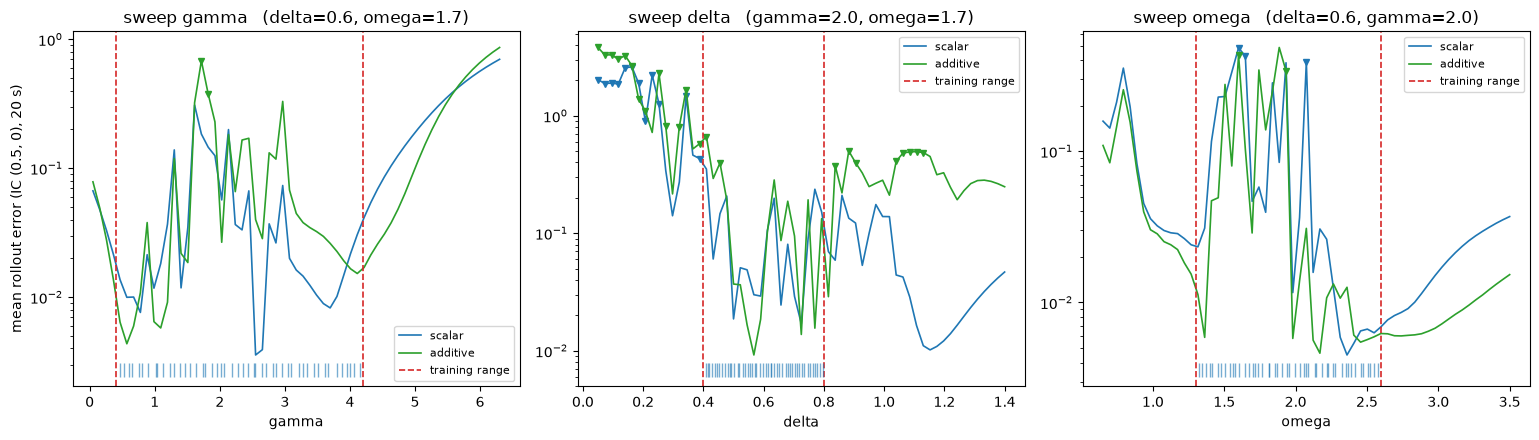

In [8]:
RAYS = [
    ('gamma', 1, np.linspace(0.05, 6.3, 61), 0.6, 1.7),
    ('delta', 0, np.linspace(0.05, 1.4, 61), None, None),
    ('omega', 2, np.linspace(0.65, 3.5, 61), None, None),
]
CENTER = {'delta': 0.6, 'gamma': 2.0, 'omega': 1.7}

ray_data = {}
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.5))
for a, (pname, j, vals, _, _2) in zip(ax, RAYS):
    phs = np.tile([CENTER['delta'], CENTER['gamma'], CENTER['omega']],
                  (len(vals), 1))
    phs[:, j] = vals
    tru = np.asarray(jax.vmap(
        lambda ph: sim_true(jnp.array([0.5, 0.0]), ph, N_SAVE))(
            jnp.asarray(phs)))
    ray_data[pname] = {'j': j, 'vals': vals, 'phs': phs}
    for tag, rhs, p, color in MODELS:
        rol = np.asarray(jax.vmap(
            lambda ph: simulate(lambda s, t: rhs(p, s, t, ph),
                                jnp.array([0.5, 0.0]), 0.0,
                                N_SAVE, DT_SAVE, 1))(jnp.asarray(phs)))
        err = np.linalg.norm(rol - tru, axis=2)
        mean_err = err.mean(axis=1)
        lost = err[:, :-1][:, lock_win].mean(axis=1) > LOCK_ERR
        ray_data[pname][tag] = (mean_err, lost)
        a.semilogy(vals, mean_err, color=color, lw=1.2, label=tag)
        a.semilogy(vals[lost], mean_err[lost], 'v', color=color, ms=5)
        print(f'{pname:6s} ray  {tag:9s} median err '
              f'{np.median(mean_err):.2e}   lost-lock: '
              f'{int(lost.sum())}/{len(vals)}')
    lo, hi = P_LO[j], P_HI[j]
    a.axvline(lo, color='tab:red', lw=1.2, ls='--')
    a.axvline(hi, color='tab:red', lw=1.2, ls='--', label='training range')
    a.plot(PARAM_SETS[:, j], np.full(N_SETS, a.get_ylim()[0]), '|',
           color='tab:blue', ms=10, alpha=0.6)
    others = [f'{n}={CENTER[n]}' for n in ('delta', 'gamma', 'omega')
              if n != pname]
    a.set_xlabel(pname)
    a.set_title(f'sweep {pname}   ({", ".join(others)})')
    a.legend(fontsize=8)
ax[0].set_ylabel('mean rollout error (IC (0.5, 0), 20 s)')
plt.tight_layout(); plt.show()

### 7b — The same rays with chaotic parameter points removed

A spike on the rays above is only a model failure if the true dynamics there are
predictable. Where the true oscillator is **chaotic**, a 20 s pointwise rollout must
diverge for *any* model — those points measure sensitivity, not skill, and they skew
the medians. So: classify every ray point by the true system's largest Lyapunov
exponent (Benettin, 50 s transient + 250 s measurement, threshold
$\lambda > 0.02\,/\mathrm{s}$), grey out the chaotic bands, and re-plot with only the
predictable oscillators. Medians and lost-lock counts are recomputed on the kept
points.

gamma  ray  scalar    (non-chaotic only, 49/61 pts)  median err 4.77e-02   lost-lock: 0/49
gamma  ray  additive  (non-chaotic only, 49/61 pts)  median err 4.46e-02   lost-lock: 0/49
delta  ray  scalar    (non-chaotic only, 33/61 pts)  median err 1.52e-01   lost-lock: 12/33
delta  ray  additive  (non-chaotic only, 33/61 pts)  median err 4.50e-01   lost-lock: 15/33


omega  ray  scalar    (non-chaotic only, 45/61 pts)  median err 2.76e-02   lost-lock: 1/45
omega  ray  additive  (non-chaotic only, 45/61 pts)  median err 1.13e-02   lost-lock: 0/45


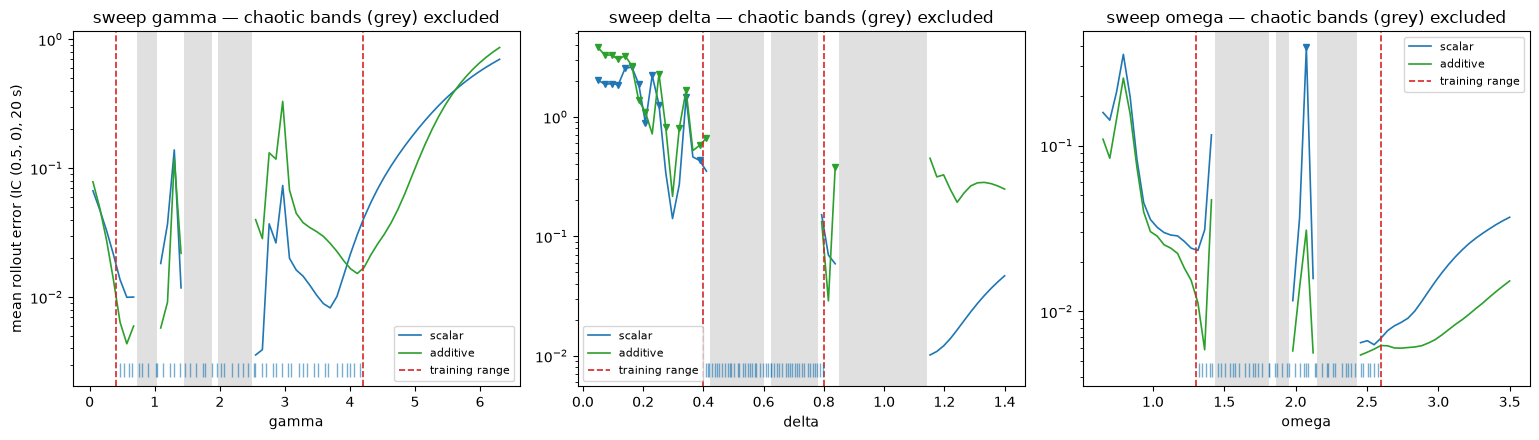

In [9]:
LAM_CHAOS = 0.02
LYAP_DT = 0.005
SEG_STEPS = 200                # renormalize every 1 s
N_TRANS_SEG, N_MEAS_SEG = 50, 250
EPS0 = 1e-8

def lyap_of(ph):
    def seg(carry, _):
        s1, s2, t, ls = carry
        def body(c, _):
            s1_, s2_, t_ = c
            f = lambda s, tt: true_rhs(s, tt, ph)
            return (rk4_step(f, s1_, t_, LYAP_DT),
                    rk4_step(f, s2_, t_, LYAP_DT), t_ + LYAP_DT), None
        (s1, s2, t), _ = jax.lax.scan(body, (s1, s2, t), None,
                                      length=SEG_STEPS)
        d = jnp.linalg.norm(s2 - s1)
        ls = ls + jnp.log(d / EPS0)
        s2 = s1 + (s2 - s1) * (EPS0 / d)
        return (s1, s2, t, ls), None

    s1 = jnp.array([0.5, 0.0])
    s2 = s1 + jnp.array([EPS0, 0.0])
    carry = (s1, s2, 0.0, 0.0)
    carry, _ = jax.lax.scan(seg, carry, None, length=N_TRANS_SEG)
    carry = (carry[0], carry[1], carry[2], 0.0)
    carry, _ = jax.lax.scan(seg, carry, None, length=N_MEAS_SEG)
    return carry[3] / (N_MEAS_SEG * SEG_STEPS * LYAP_DT)

lyap_batch = jax.jit(jax.vmap(lyap_of))

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.5))
for a, (pname, j, vals, _, _2) in zip(ax, RAYS):
    rd = ray_data[pname]
    lams = np.asarray(lyap_batch(jnp.asarray(rd['phs'])))
    chaotic = lams > LAM_CHAOS
    keep = ~chaotic
    dv = vals[1] - vals[0]
    for v_, c_ in zip(vals, chaotic):
        if c_:
            a.axvspan(v_ - dv / 2, v_ + dv / 2, color='0.88', lw=0,
                      zorder=0)
    for tag, _, _, color in MODELS:
        mean_err, lost = rd[tag]
        shown = np.where(keep, mean_err, np.nan)
        a.semilogy(vals, shown, color=color, lw=1.2, label=tag)
        lk = lost & keep
        a.semilogy(vals[lk], mean_err[lk], 'v', color=color, ms=5)
        print(f'{pname:6s} ray  {tag:9s} (non-chaotic only, '
              f'{int(keep.sum())}/{len(vals)} pts)  median err '
              f'{np.median(mean_err[keep]):.2e}   lost-lock: '
              f'{int(lk.sum())}/{int(keep.sum())}')
    lo, hi = P_LO[j], P_HI[j]
    a.axvline(lo, color='tab:red', lw=1.2, ls='--')
    a.axvline(hi, color='tab:red', lw=1.2, ls='--', label='training range')
    a.plot(PARAM_SETS[:, j], np.full(N_SETS, a.get_ylim()[0]), '|',
           color='tab:blue', ms=10, alpha=0.6)
    a.set_xlabel(pname)
    a.set_title(f'sweep {pname} — chaotic bands (grey) excluded')
    a.legend(fontsize=8)
ax[0].set_ylabel('mean rollout error (IC (0.5, 0), 20 s)')
plt.tight_layout(); plt.show()

## 8 — The learned force laws, across the family

The additive model's term-by-term report card, now with parameter axes:

- $f_\theta(x)$ — one curve for the whole family, against $x - x^3$;
- $d_\theta(\dot{x}, \delta)$ at three $\delta$ values, against the lines
  $-\delta\dot{x}$ — is the learned surface linear in both arguments?
- $g_\theta$ over one drive cycle at three $(\gamma, \omega)$ combinations, against
  $\gamma\cos\omega t$ — and the $\omega$-independence check: same $\gamma$, two
  different $\omega$, plotted against phase $\theta = \omega t$; the truth is one
  curve, so any gap is $g$ using the redundant $\omega$ input.

Gauge: only a single global constant can shuttle between the three terms now
(a $\delta$-dependent offset in $d$ has nowhere to hide — nothing else takes
$\delta$), fixed by $d(0, 0.6) = 0$ and zero-mean $g$ at the reference
$(\gamma, \omega) = (2.0, 1.7)$, both absorbed into $f$.

gauge constants:  mean(g at ref) = +0.4133   d(0, 0.6) = +0.0993


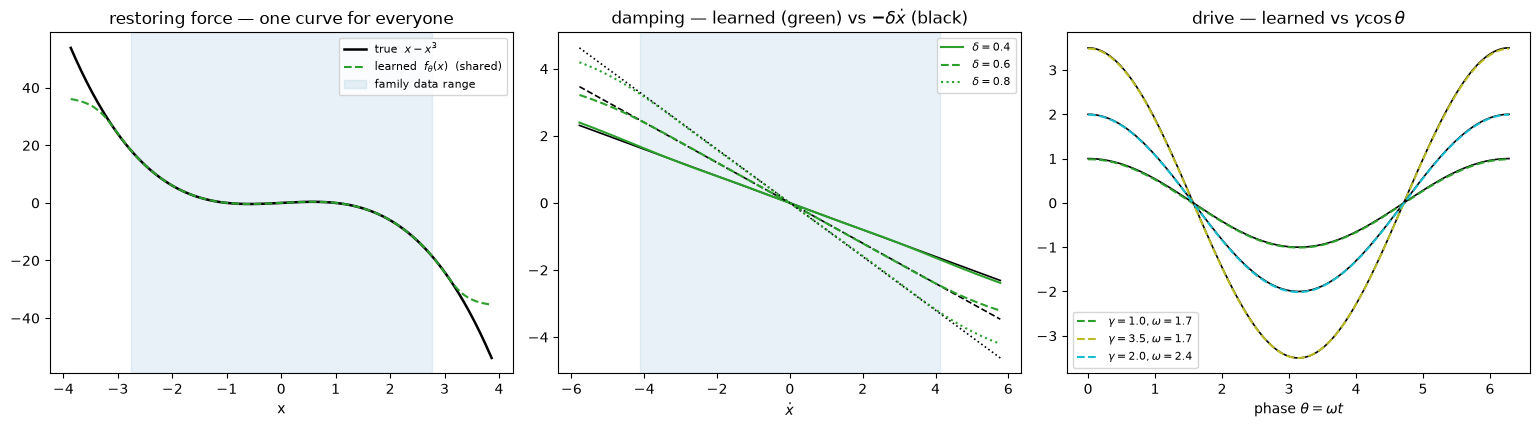

max |f error|  in family data range: 3.24e-02   at plot edges: 1.85e+01
max |d error|  delta=0.4: 3.82e-02
max |d error|  delta=0.6: 1.02e-02
max |d error|  delta=0.8: 4.46e-02
omega-independence of g: max |g(gamma=2, omega=1.4) - g(gamma=2, omega=2.4)| over a cycle = 1.21e-02   (truth: 0)


In [10]:
def d_term(v, delta):
    return additive_terms(params_a, jnp.array([0.0, v]), 0.0,
                          jnp.array([delta, 2.0, 1.7]))[1]

def g_term(t, gamma, omega):
    return additive_terms(params_a, jnp.array([0.0, 0.0]), t,
                          jnp.array([0.6, gamma, omega]))[2]

def f_term(x):
    return additive_terms(params_a, jnp.array([x, 0.0]), 0.0,
                          jnp.array([0.6, 2.0, 1.7]))[0]

th = np.linspace(0.0, 2 * np.pi, 200)
g_ref = np.asarray(jax.vmap(lambda t: g_term(t, 2.0, 1.7))(
    jnp.asarray(th / 1.7)))
c_g = g_ref.mean()
c_d = float(d_term(0.0, 0.6))
print(f'gauge constants:  mean(g at ref) = {c_g:+.4f}   d(0, 0.6) = {c_d:+.4f}')

XMAX = float(EXT[:, 0].max())
VMAX = float(EXT[:, 1].max())
x_plot = np.linspace(-1.4 * XMAX, 1.4 * XMAX, 400)
v_plot = np.linspace(-1.4 * VMAX, 1.4 * VMAX, 400)
f_vals = np.asarray(jax.vmap(f_term)(jnp.asarray(x_plot))) + c_g + c_d

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.4))
a = ax[0]
a.plot(x_plot, x_plot - x_plot**3, 'k', lw=1.8, label='true  $x - x^3$')
a.plot(x_plot, f_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $f_\theta(x)$  (shared)')
a.axvspan(-XMAX, XMAX, color='tab:blue', alpha=0.10, label='family data range')
a.set_xlabel('x'); a.set_title('restoring force — one curve for everyone')
a.legend(fontsize=8)

a = ax[1]
for delta, ls in [(0.4, '-'), (0.6, '--'), (0.8, ':')]:
    a.plot(v_plot, -delta * v_plot, 'k', lw=1.2, ls=ls)
    dv = np.asarray(jax.vmap(lambda v: d_term(v, delta))(
        jnp.asarray(v_plot))) - c_d
    a.plot(v_plot, dv, ls, color='tab:green', lw=1.5,
           label=f'$\\delta = {delta}$')
a.axvspan(-VMAX, VMAX, color='tab:blue', alpha=0.10)
a.set_xlabel(r'$\dot{x}$')
a.set_title(r'damping — learned (green) vs $-\delta\dot{x}$ (black)')
a.legend(fontsize=8)

a = ax[2]
for gamma, omega, color in [(1.0, 1.7, 'tab:green'), (3.5, 1.7, 'tab:olive'),
                            (2.0, 2.4, 'tab:cyan')]:
    a.plot(th, gamma * np.cos(th), 'k', lw=1.2)
    gv = np.asarray(jax.vmap(lambda t: g_term(t, gamma, omega))(
        jnp.asarray(th / omega))) - c_g
    a.plot(th, gv, '--', color=color, lw=1.5,
           label=f'$\\gamma={gamma}, \\omega={omega}$')
a.set_xlabel(r'phase $\theta = \omega t$')
a.set_title(r'drive — learned vs $\gamma\cos\theta$')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

in_x = np.abs(x_plot) <= XMAX
print(f'max |f error|  in family data range: '
      f'{np.abs(f_vals - (x_plot - x_plot**3))[in_x].max():.2e}'
      f'   at plot edges: '
      f'{np.abs(f_vals - (x_plot - x_plot**3))[[0, -1]].max():.2e}')
for delta in (0.4, 0.6, 0.8):
    dv = np.asarray(jax.vmap(lambda v: d_term(v, delta))(
        jnp.asarray(v_plot))) - c_d
    iv = np.abs(v_plot) <= VMAX
    print(f'max |d error|  delta={delta}: '
          f'{np.abs(dv + delta * v_plot)[iv].max():.2e}')
g_w1 = np.asarray(jax.vmap(lambda t: g_term(t, 2.0, 1.4))(
    jnp.asarray(th / 1.4)))
g_w2 = np.asarray(jax.vmap(lambda t: g_term(t, 2.0, 2.4))(
    jnp.asarray(th / 2.4)))
print(f'omega-independence of g: max |g(gamma=2, omega=1.4) - '
      f'g(gamma=2, omega=2.4)| over a cycle = {np.abs(g_w1 - g_w2).max():.2e}'
      f'   (truth: 0)')

## What this rung settles

1. **Family vs memorization**: Section 6 is the verdict — if unseen interior
   parameter draws roll out as well as trained ones, the model learned the *map*
   $(\text{state}, \text{phase}, \delta, \gamma, \omega) \to a$, not 48 oscillators.
2. **Parameter extrapolation**: the rays in Section 7 are the new frontier of the
   trust-region story. Prediction to falsify: the additive model degrades gently
   along $\delta$ (its damping term sees $\delta$ through what is nearly a linear
   law) and $\gamma$ (linear in the drive), while the scalar model — which must
   discover how each parameter threads through a 7-input black box — falls off
   faster outside the box.
3. **The force surfaces** (Section 8) are the mechanism check: a shared $f$, a
   $d$-plane linear in both $\dot{x}$ and $\delta$, a drive linear in $\gamma$ that
   ignores its redundant $\omega$ input — each one the family-level law recovered
   from data.

Natural next rungs: hold out the four historic parameter points and re-run the
Step 5/6 structure tests (period-8 table at never-trained parameters); the polynomial
skeleton for $f$, now buying extrapolation for the *entire family* at once; parameter
sweeps of the learned model to reproduce atlas slices (bifurcation diagrams from a
neural ODE).


---

# Part B — Step 8: the chaos-free box

δ∈[0.7,1], γ∈[3.5,4], ω∈[1.9,2.9], verified 0/48 chaotic. Clean interpolation verdict + spike autopsy.

---


# Duffing Neural ODE — Step 8: the family, chaos-free

Until now every model owned exactly one oscillator. This notebook feeds the physical
parameters to the network and learns the **map from $(x, \dot{x}, \text{phase},
\delta, \gamma, \omega)$ to acceleration** — one model for the entire Duffing family
over

$$\delta \in [0.7, 1.0], \qquad \gamma \in [3.5, 4.0], \qquad \omega \in [1.9, 2.9],$$

a box Nick selected from the atlas to be **chaos-free**: verified by the Benettin
classifier — 0/48 training draws and 0/12 eval draws chaotic (λ ∈ [−0.49, −0.008]).
It still spans single-well and cross-well responses and multi-period orbits (the
near-zero-λ draws), so every oscillator in the family is *predictable*: rollout error
now measures the models, not sensitivity.

Two models, matched to the Step 5–6 finalists but with the new inputs:

| model | acceleration | inputs | params |
|---|---|---|---|
| **scalar** | one MLP, 1 output | $(x, \dot{x}, \cos\omega t, \sin\omega t, \delta, \gamma, \omega)$ flat | ~4.7k |
| **additive** | $f_\theta(x) + d_\theta(\dot{x}, \delta) + g_\theta(\cos\omega t, \sin\omega t, \gamma, \omega)$ | routed | ~3.6k |

The additive routing now encodes *parameter* physics on top of the force split:
$f$ takes **no parameters** (the restoring force is shared by the whole family — and
gets trained by every trajectory of every oscillator), $\delta$ can only touch the
damping term, and $\gamma, \omega$ can only touch the drive. Two claims the truth
satisfies ($f = x - x^3$ for everyone; $d = -\delta\dot{x}$; $g = \gamma\cos\omega t$)
and the black box has to discover on its own. One deliberate redundancy: $g$ receives
$\omega$ even though the phase pair already encodes it — whether $g$ *learns to ignore
$\omega$* becomes an evaluation.

Data: 48 Latin-hypercube parameter draws × 21 ICs each (7×3 grid auto-scaled to that
oscillator's own attractor extent) × 20 s → **~2M training pairs**. Evaluations focus
on the new dimension: held-out ICs at trained parameters, **unseen interior parameter
draws** (parameter interpolation), and **parameter-extrapolation rays** marching
$\delta$, $\gamma$, $\omega$ out of the training box.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

P_LO = np.array([0.7, 3.5, 1.9])   # delta, gamma, omega
P_HI = np.array([1.0, 4.0, 2.9])
N_SETS = 48
N_EVAL_SETS = 12

def true_rhs(s, t, ph):
    x, v = s
    delta, gamma, omega = ph
    return jnp.array([v, -delta * v + x - x**3 + gamma * jnp.cos(omega * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

DT_INT, DT_SAVE = 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))

def sim_true(s0, ph, n_save, substeps=SUBS):
    return simulate(lambda s, t: true_rhs(s, t, ph), jnp.asarray(s0), 0.0,
                    n_save, DT_SAVE, substeps)

def lhs_box(n, lo, hi, rng):
    out = np.empty((n, len(lo)))
    for j in range(len(lo)):
        out[:, j] = lo[j] + (hi[j] - lo[j]) * \
            (rng.permutation(n) + rng.uniform(size=n)) / n
    return out

rng = np.random.default_rng(42)
PARAM_SETS = lhs_box(N_SETS, P_LO, P_HI, rng)
print('48 training parameter sets (Latin hypercube), first 5:')
for ph in PARAM_SETS[:5]:
    print(f'   delta={ph[0]:.3f}  gamma={ph[1]:.3f}  omega={ph[2]:.3f}')

48 training parameter sets (Latin hypercube), first 5:
   delta=0.934  gamma=3.994  omega=2.166
   delta=0.889  gamma=3.565  omega=2.364
   delta=0.982  gamma=3.837  omega=1.920
   delta=0.915  gamma=3.662  omega=2.863
   delta=0.733  gamma=3.804  omega=2.403


## 1 — Training data: 48 oscillators × 21 ICs

For each parameter set: a 120 s pre-sim measures that oscillator's attractor extent,
the 7×3 IC grid is scaled to 80% of it, and 21 trajectories of 20 s are generated.
Chaotic parameter draws are welcome — one-step training only needs the vector field
sampled broadly, not tidy orbits.

In [2]:
T_PRE = 120.0
N_PRE = int(round(T_PRE / DT_SAVE))
pre = np.asarray(jax.vmap(
    lambda ph: sim_true(jnp.array([0.5, 0.0]), ph, N_PRE))(
        jnp.asarray(PARAM_SETS)))
tail = pre[:, int(40.0 / DT_SAVE):, :]
EXT = np.abs(tail).max(axis=1)           # (48, 2)
BOX = np.round(0.8 * EXT, 1)
print('attractor extent across the family:')
print(f'   |x|: min {EXT[:, 0].min():.2f}  max {EXT[:, 0].max():.2f}')
print(f'   |v|: min {EXT[:, 1].min():.2f}  max {EXT[:, 1].max():.2f}')

N_IC_X, N_IC_V = 7, 3
N_ICS = N_IC_X * N_IC_V
T_END = 20.0
N_SAVE = int(round(T_END / DT_SAVE))
times = np.arange(N_SAVE + 1) * DT_SAVE

ic_all, ph_all = [], []
for k in range(N_SETS):
    g = np.stack(np.meshgrid(np.linspace(-BOX[k, 0], BOX[k, 0], N_IC_X),
                             np.linspace(-BOX[k, 1], BOX[k, 1], N_IC_V),
                             indexing='ij'), axis=-1).reshape(-1, 2)
    ic_all.append(g)
    ph_all.append(np.repeat(PARAM_SETS[k][None], N_ICS, axis=0))
ic_all = np.concatenate(ic_all)          # (1008, 2)
ph_all = np.concatenate(ph_all)          # (1008, 3)

trajs = np.asarray(jax.vmap(lambda s0, ph: sim_true(s0, ph, N_SAVE))(
    jnp.asarray(ic_all), jnp.asarray(ph_all)))
print('training trajectories:', trajs.shape)

s_now = jnp.asarray(trajs[:, :-1, :].reshape(-1, 2))
s_next = jnp.asarray(trajs[:, 1:, :].reshape(-1, 2))
t_now = jnp.asarray(np.tile(times[:-1], len(ic_all)))
p_now = jnp.asarray(np.repeat(ph_all, N_SAVE, axis=0))
N_PAIRS = s_now.shape[0]
print(f'training pairs: {N_PAIRS:,}')

attractor extent across the family:
   |x|: min 0.85  max 1.77
   |v|: min 1.38  max 2.58
training trajectories: (1008, 2001, 2)
training pairs: 2,016,000


## 2 — The two models

In [3]:
def init_mlp(key, layers):
    params = []
    for n_in, n_out in zip(layers[:-1], layers[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def mlp(params, u):
    h = u
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

LAYERS_SCALAR = [7, 64, 64, 1]
def init_scalar(key):
    return init_mlp(key, LAYERS_SCALAR)
def rhs_scalar(params, s, t, ph):
    delta, gamma, omega = ph
    u = jnp.array([s[0], s[1], jnp.cos(omega * t), jnp.sin(omega * t),
                   delta, gamma, omega])
    return jnp.array([s[1], mlp(params, u)[0]])

F_LAYERS = [1, 32, 32, 1]
D_LAYERS = [2, 32, 32, 1]
G_LAYERS = [4, 32, 32, 1]
N_F, N_D = len(F_LAYERS) - 1, len(D_LAYERS) - 1

def init_additive(key):
    kf, kd, kg = jax.random.split(key, 3)
    return (init_mlp(kf, F_LAYERS) + init_mlp(kd, D_LAYERS)
            + init_mlp(kg, G_LAYERS))

def additive_terms(params, s, t, ph):
    delta, gamma, omega = ph
    pf = params[:N_F]
    pd = params[N_F:N_F + N_D]
    pg = params[N_F + N_D:]
    f = mlp(pf, jnp.array([s[0]]))[0]
    d = mlp(pd, jnp.array([s[1], delta]))[0]
    g = mlp(pg, jnp.array([jnp.cos(omega * t), jnp.sin(omega * t),
                           gamma, omega]))[0]
    return f, d, g

def rhs_additive(params, s, t, ph):
    f, d, g = additive_terms(params, s, t, ph)
    return jnp.array([s[1], f + d + g])

for name, init in [('scalar', init_scalar), ('additive', init_additive)]:
    n = sum(W.size + b.size for W, b in init(jax.random.PRNGKey(0)))
    print(f'{name:9s} parameters: {n}')

scalar    parameters: 4737


additive  parameters: 3587


## 3 — Training

Same one-step harness, scaled up: 30k Adam steps (lr 1e-3 → 1e-4 at 20k), batch
16,384 drawn from the 2M-pair pool. The tracked loss is on a fixed 131k-pair random
subset (evaluating all 2M every 500 steps would dominate the run). Caches
`params_family_<model>.npz` — delete to retrain.

In [4]:
import os

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

BATCH = 16384
N_STEPS = 30000
LR_DROP = 20000
EVAL_EVERY = 500
EVAL_IDX = jnp.asarray(np.random.default_rng(3).choice(N_PAIRS, 131072,
                                                       replace=False))

def train(rhs, init_fn, model_tag):
    def one_step(params, s, t, ph):
        return rk4_step(lambda s_, t_: rhs(params, s_, t_, ph), s, t, DT_SAVE)

    def loss_on(params, sb, snb, tb, pb):
        pred = jax.vmap(lambda s, t, ph: one_step(params, s, t, ph))(sb, tb, pb)
        return jnp.mean((pred - snb) ** 2)

    eval_loss = jax.jit(lambda p: loss_on(p, s_now[EVAL_IDX], s_next[EVAL_IDX],
                                          t_now[EVAL_IDX], p_now[EVAL_IDX]))

    cache = f'params_family2_{model_tag}.npz'
    if os.path.exists(cache):
        z = np.load(cache)
        n_layers = sum(1 for k in z.files if k.startswith('W'))
        params = [(jnp.asarray(z[f'W{i}']), jnp.asarray(z[f'b{i}']))
                  for i in range(n_layers)]
        print(f'[{model_tag}] loaded cached params from {cache}   '
              f'eval loss {float(eval_loss(params)):.3e}   '
              f'(delete the file to retrain)')
        return (params, z['hist_steps'], z['hist_loss'], float(z['wall']))

    @jax.jit
    def train_step(params, m, v, step, lr, key):
        idx = jax.random.randint(key, (BATCH,), 0, N_PAIRS)
        loss, grads = jax.value_and_grad(loss_on)(
            params, s_now[idx], s_next[idx], t_now[idx], p_now[idx])
        params, m, v = adam_update(params, grads, m, v, step, lr)
        return params, m, v, loss

    params = init_fn(jax.random.PRNGKey(0))
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    base_key = jax.random.PRNGKey(1)

    hist_steps, hist_loss = [], []
    t0 = time.time()
    for i in range(1, N_STEPS + 1):
        lr = 1e-3 if i <= LR_DROP else 1e-4
        params, m, v, _ = train_step(params, m, v, float(i), lr,
                                     jax.random.fold_in(base_key, i))
        if i == 1 or i % EVAL_EVERY == 0:
            fl = float(eval_loss(params))
            hist_steps.append(i)
            hist_loss.append(fl)
            if i == 1 or i % 5000 == 0:
                print(f'[{model_tag}] step {i:6d}   lr {lr:.0e}'
                      f'   eval loss {fl:.3e}')
    wall = time.time() - t0
    print(f'[{model_tag}] final eval loss {hist_loss[-1]:.3e}'
          f'   wall time {wall:.0f} s')
    np.savez(cache, hist_steps=np.array(hist_steps),
             hist_loss=np.array(hist_loss), wall=wall,
             **{f'W{i}': np.asarray(Wt) for i, (Wt, _) in enumerate(params)},
             **{f'b{i}': np.asarray(bt) for i, (_, bt) in enumerate(params)})
    return params, np.array(hist_steps), np.array(hist_loss), wall

params_s, steps_s, loss_s, wall_s = train(rhs_scalar, init_scalar, 'scalar')
params_a, steps_a, loss_a, wall_a = train(rhs_additive, init_additive,
                                          'additive')

MODELS = [('scalar', rhs_scalar, params_s, 'tab:blue'),
          ('additive', rhs_additive, params_a, 'tab:green')]

[scalar] loaded cached params from params_family2_scalar.npz   eval loss 4.635e-09   (delete the file to retrain)


[additive] loaded cached params from params_family2_additive.npz   eval loss 3.566e-09   (delete the file to retrain)


## 4 — Learning curves

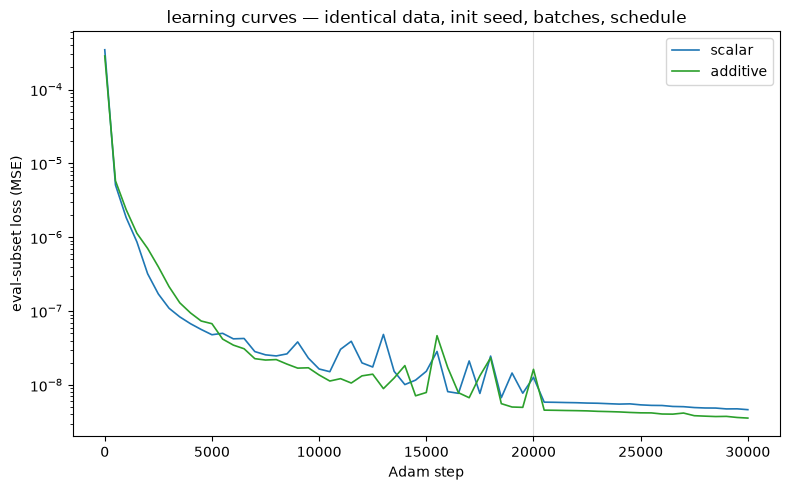

final loss   scalar 4.635e-09   additive 3.566e-09
wall time    scalar 343 s   additive 364 s


In [5]:
fig, a = plt.subplots(figsize=(8, 5))
for (tag, _, _, color), st, lo in [(MODELS[0], steps_s, loss_s),
                                   (MODELS[1], steps_a, loss_a)]:
    a.semilogy(st, lo, color=color, lw=1.2, label=tag)
a.axvline(LR_DROP, color='0.85', lw=0.8, zorder=0)
a.set_xlabel('Adam step')
a.set_ylabel('eval-subset loss (MSE)')
a.set_title('learning curves — identical data, init seed, batches, schedule')
a.legend()
plt.tight_layout(); plt.show()

print(f'final loss   scalar {loss_s[-1]:.3e}   additive {loss_a[-1]:.3e}')
print(f'wall time    scalar {wall_s:.0f} s   additive {wall_a:.0f} s')

## 5 — One-step errors and held-out ICs at trained parameters

One-step error over all 2M pairs (chunked), then 20 s rollouts from held-out interior
ICs at four of the 48 trained parameter sets — the easiest ask: same oscillators,
new starts.

In [6]:
def one_step_errors(rhs, params):
    f = jax.jit(jax.vmap(lambda s, t, ph: rk4_step(
        lambda s_, t_: rhs(params, s_, t_, ph), s, t, DT_SAVE)))
    errs = []
    CH = 262144
    for i in range(0, N_PAIRS, CH):
        pred = f(s_now[i:i + CH], t_now[i:i + CH], p_now[i:i + CH])
        errs.append(np.asarray(
            jnp.linalg.norm(pred - s_next[i:i + CH], axis=1)))
    return np.concatenate(errs)

for tag, rhs, p, _ in MODELS:
    e = one_step_errors(rhs, p)
    print(f'{tag:9s} one-step error   median {np.median(e):.2e}'
          f'   mean {e.mean():.2e}   max {e.max():.2e}')

LOCK_ERR = 1.0
lock_win = times[:-1] >= T_END - 5.0

def rollout_err(rhs, params, ic, ph):
    tru = np.asarray(sim_true(ic, jnp.asarray(ph), N_SAVE))
    rol = np.asarray(simulate(lambda s, t: rhs(params, s, t, jnp.asarray(ph)),
                              jnp.asarray(ic), 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    return err.mean(), err[:-1][lock_win].mean() < LOCK_ERR

FRACS = [(0.44, 0.42), (-0.81, -0.72), (0.93, 0.87)]
SHOW_SETS = [0, 13, 27, 41]
print()
print('held-out ICs at trained parameter sets (mean rollout error, 20 s):')
print(f'{"params (d, g, w)":>26s} {"IC":>15s} {"scalar":>11s} {"additive":>11s}'
      '   locked?')
for k in SHOW_SETS:
    ph = PARAM_SETS[k]
    for fx, fv in FRACS:
        ic = (round(fx * BOX[k, 0], 2), round(fv * BOX[k, 1], 2))
        row, locks = [], []
        for tag, rhs, p, _ in MODELS:
            e, l = rollout_err(rhs, p, jnp.array(ic), ph)
            row.append(e)
            locks.append(l)
        lab = f'({ph[0]:.2f}, {ph[1]:.2f}, {ph[2]:.2f})'
        print(f'{lab:>26s} {str(ic):>15s} {row[0]:>11.2e} {row[1]:>11.2e}'
              f'   {locks[0]} / {locks[1]}')

scalar    one-step error   median 4.40e-05   mean 6.16e-05   max 2.55e-03


additive  one-step error   median 4.40e-05   mean 5.54e-05   max 4.26e-03

held-out ICs at trained parameter sets (mean rollout error, 20 s):
          params (d, g, w)              IC      scalar    additive   locked?


        (0.93, 3.99, 2.17) (np.float64(0.4), np.float64(0.55))    1.26e-02    3.27e-03   True / True


        (0.93, 3.99, 2.17) (np.float64(-0.73), np.float64(-0.94))    6.87e-02    7.58e-02   True / True


        (0.93, 3.99, 2.17) (np.float64(0.84), np.float64(1.13))    9.46e-02    1.30e-01   True / True


...

        (0.90, 3.97, 2.08) (np.float64(-0.65), np.float64(-0.94))    1.77e-02    1.87e-02   True / True


        (0.90, 3.97, 2.08) (np.float64(0.74), np.float64(1.13))    1.89e-02    1.81e-02   True / True


        (0.99, 3.51, 2.34) (np.float64(0.44), np.float64(0.5))    1.15e-02    7.39e-03   True / True


        (0.99, 3.51, 2.34) (np.float64(-0.81), np.float64(-0.86))    1.21e-02    5.67e-03   True / True


        (0.99, 3.51, 2.34) (np.float64(0.93), np.float64(1.04))    1.94e-02    5.98e-03   True / True


## 6 — Parameter interpolation: 12 unseen parameter draws

The new dimension's core test. Twelve fresh Latin-hypercube draws from the *same box*
— oscillators the models have never seen — three held-out ICs each (scaled to each
oscillator's own measured extent). If the models learned the family and not 48
oscillators, these numbers should look like Section 5's.

In [7]:
EVAL_SETS = lhs_box(N_EVAL_SETS, P_LO, P_HI, np.random.default_rng(7))
pre_e = np.asarray(jax.vmap(
    lambda ph: sim_true(jnp.array([0.5, 0.0]), ph, N_PRE))(
        jnp.asarray(EVAL_SETS)))
EXT_E = np.abs(pre_e[:, int(40.0 / DT_SAVE):, :]).max(axis=1)

print('unseen interior parameter draws (mean rollout error, 20 s):')
print(f'{"params (d, g, w)":>26s} {"IC":>15s} {"scalar":>11s} {"additive":>11s}'
      '   locked?')
all_err = {tag: [] for tag, *_ in MODELS}
for k in range(N_EVAL_SETS):
    ph = EVAL_SETS[k]
    lims = 0.8 * EXT_E[k]
    for fx, fv in FRACS:
        ic = (round(fx * lims[0], 2), round(fv * lims[1], 2))
        row, locks = [], []
        for tag, rhs, p, _ in MODELS:
            e, l = rollout_err(rhs, p, jnp.array(ic), ph)
            row.append(e)
            locks.append(l)
            all_err[tag].append(e)
        lab = f'({ph[0]:.2f}, {ph[1]:.2f}, {ph[2]:.2f})'
        print(f'{lab:>26s} {str(ic):>15s} {row[0]:>11.2e} {row[1]:>11.2e}'
              f'   {locks[0]} / {locks[1]}')
print()
for tag, *_ in MODELS:
    e = np.array(all_err[tag])
    print(f'{tag:9s} over all 36 unseen-param rollouts:'
          f'   median {np.median(e):.2e}   mean {e.mean():.2e}'
          f'   max {e.max():.2e}')

unseen interior parameter draws (mean rollout error, 20 s):
          params (d, g, w)              IC      scalar    additive   locked?


        (0.82, 3.69, 2.24) (np.float64(0.44), np.float64(0.54))    9.31e-03    4.68e-02   True / True


        (0.82, 3.69, 2.24) (np.float64(-0.8), np.float64(-0.92))    2.38e-02    3.68e-03   True / True


        (0.82, 3.69, 2.24) (np.float64(0.92), np.float64(1.12))    1.14e-02    3.86e-02   True / True


        (0.87, 3.54, 2.20) (np.float64(0.44), np.float64(0.53))    3.98e-02    7.09e-02   True / True


...

        (0.94, 3.89, 2.38) (np.float64(-0.82), np.float64(-0.93))    7.03e-02    7.73e-02   True / True


        (0.94, 3.89, 2.38) (np.float64(0.94), np.float64(1.12))    1.19e-01    7.74e-02   True / True


        (0.99, 3.63, 2.68) (np.float64(0.46), np.float64(0.49))    7.86e-03    4.47e-03   True / True


        (0.99, 3.63, 2.68) (np.float64(-0.84), np.float64(-0.83))    2.43e-02    2.07e-02   True / True


        (0.99, 3.63, 2.68) (np.float64(0.97), np.float64(1.0))    2.75e-02    1.38e-02   True / True

scalar    over all 36 unseen-param rollouts:   median 2.14e-02   mean 3.23e-02   max 1.19e-01
additive  over all 36 unseen-param rollouts:   median 2.28e-02   mean 3.17e-02   max 1.24e-01


## 7 — Parameter-extrapolation rays

The parameter-space analog of the IC rays: fix the IC at $(0.5, 0)$ and march one
parameter through and past the training box (red dashed = box edges; rug ticks =
the 48 training values of that parameter). Held-out center values for the other two
parameters. Where does the family model stop being trustworthy in *parameter* space?

gamma  ray  scalar    median err 4.58e-02   lost-lock: 0/61


gamma  ray  additive  median err 6.67e-02   lost-lock: 0/61


delta  ray  scalar    median err 3.84e-02   lost-lock: 10/61


delta  ray  additive  median err 8.57e-02   lost-lock: 9/61


omega  ray  scalar    median err 1.36e-02   lost-lock: 0/61


omega  ray  additive  median err 1.28e-02   lost-lock: 1/61


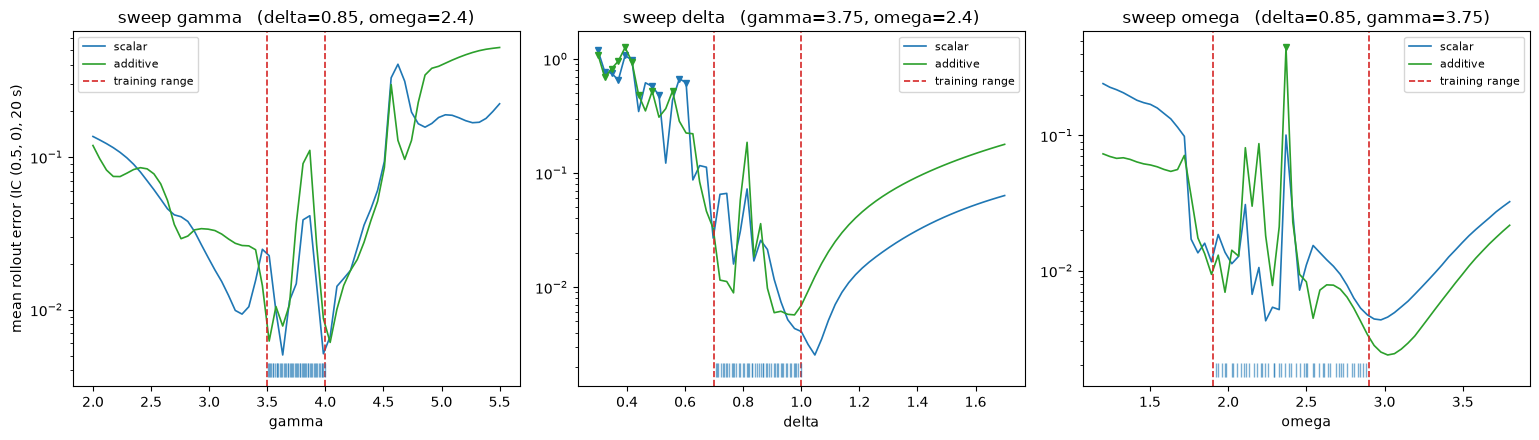

In [8]:
RAYS = [
    ('gamma', 1, np.linspace(2.0, 5.5, 61), None, None),
    ('delta', 0, np.linspace(0.3, 1.7, 61), None, None),
    ('omega', 2, np.linspace(1.2, 3.8, 61), None, None),
]
CENTER = {'delta': 0.85, 'gamma': 3.75, 'omega': 2.4}

ray_data = {}
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.5))
for a, (pname, j, vals, _, _2) in zip(ax, RAYS):
    phs = np.tile([CENTER['delta'], CENTER['gamma'], CENTER['omega']],
                  (len(vals), 1))
    phs[:, j] = vals
    tru = np.asarray(jax.vmap(
        lambda ph: sim_true(jnp.array([0.5, 0.0]), ph, N_SAVE))(
            jnp.asarray(phs)))
    ray_data[pname] = {'j': j, 'vals': vals, 'phs': phs}
    for tag, rhs, p, color in MODELS:
        rol = np.asarray(jax.vmap(
            lambda ph: simulate(lambda s, t: rhs(p, s, t, ph),
                                jnp.array([0.5, 0.0]), 0.0,
                                N_SAVE, DT_SAVE, 1))(jnp.asarray(phs)))
        err = np.linalg.norm(rol - tru, axis=2)
        mean_err = err.mean(axis=1)
        lost = err[:, :-1][:, lock_win].mean(axis=1) > LOCK_ERR
        ray_data[pname][tag] = (mean_err, lost)
        a.semilogy(vals, mean_err, color=color, lw=1.2, label=tag)
        a.semilogy(vals[lost], mean_err[lost], 'v', color=color, ms=5)
        print(f'{pname:6s} ray  {tag:9s} median err '
              f'{np.median(mean_err):.2e}   lost-lock: '
              f'{int(lost.sum())}/{len(vals)}')
    lo, hi = P_LO[j], P_HI[j]
    a.axvline(lo, color='tab:red', lw=1.2, ls='--')
    a.axvline(hi, color='tab:red', lw=1.2, ls='--', label='training range')
    a.plot(PARAM_SETS[:, j], np.full(N_SETS, a.get_ylim()[0]), '|',
           color='tab:blue', ms=10, alpha=0.6)
    others = [f'{n}={CENTER[n]}' for n in ('delta', 'gamma', 'omega')
              if n != pname]
    a.set_xlabel(pname)
    a.set_title(f'sweep {pname}   ({", ".join(others)})')
    a.legend(fontsize=8)
ax[0].set_ylabel('mean rollout error (IC (0.5, 0), 20 s)')
plt.tight_layout(); plt.show()

### 7b — Inside the spikes: what the models actually do there

For each ray, take the worst in-box parameter point and look at it directly. Top row:
the 20 s rollout from IC $(0.5, 0)$ that the error metric scored — truth in black,
models dashed. Bottom row: the long-run test — everyone runs 200 s and we overlay the
final 50 s (the settled orbits). If a spike is a *phase slip* or a *wrong-attractor
pick*, the bottom panel shows the learned orbit lying on (or mirroring) the true one
even though the top panel disagrees; if a model has genuinely wrong dynamics, its
settled orbit has the wrong shape entirely.

gamma  spike: params (0.850, 3.867, 2.400)   worst mean err 1.11e-01
delta  spike: params (0.813, 3.750, 2.400)   worst mean err 1.86e-01
omega  spike: params (0.850, 3.750, 2.370)   worst mean err 4.48e-01


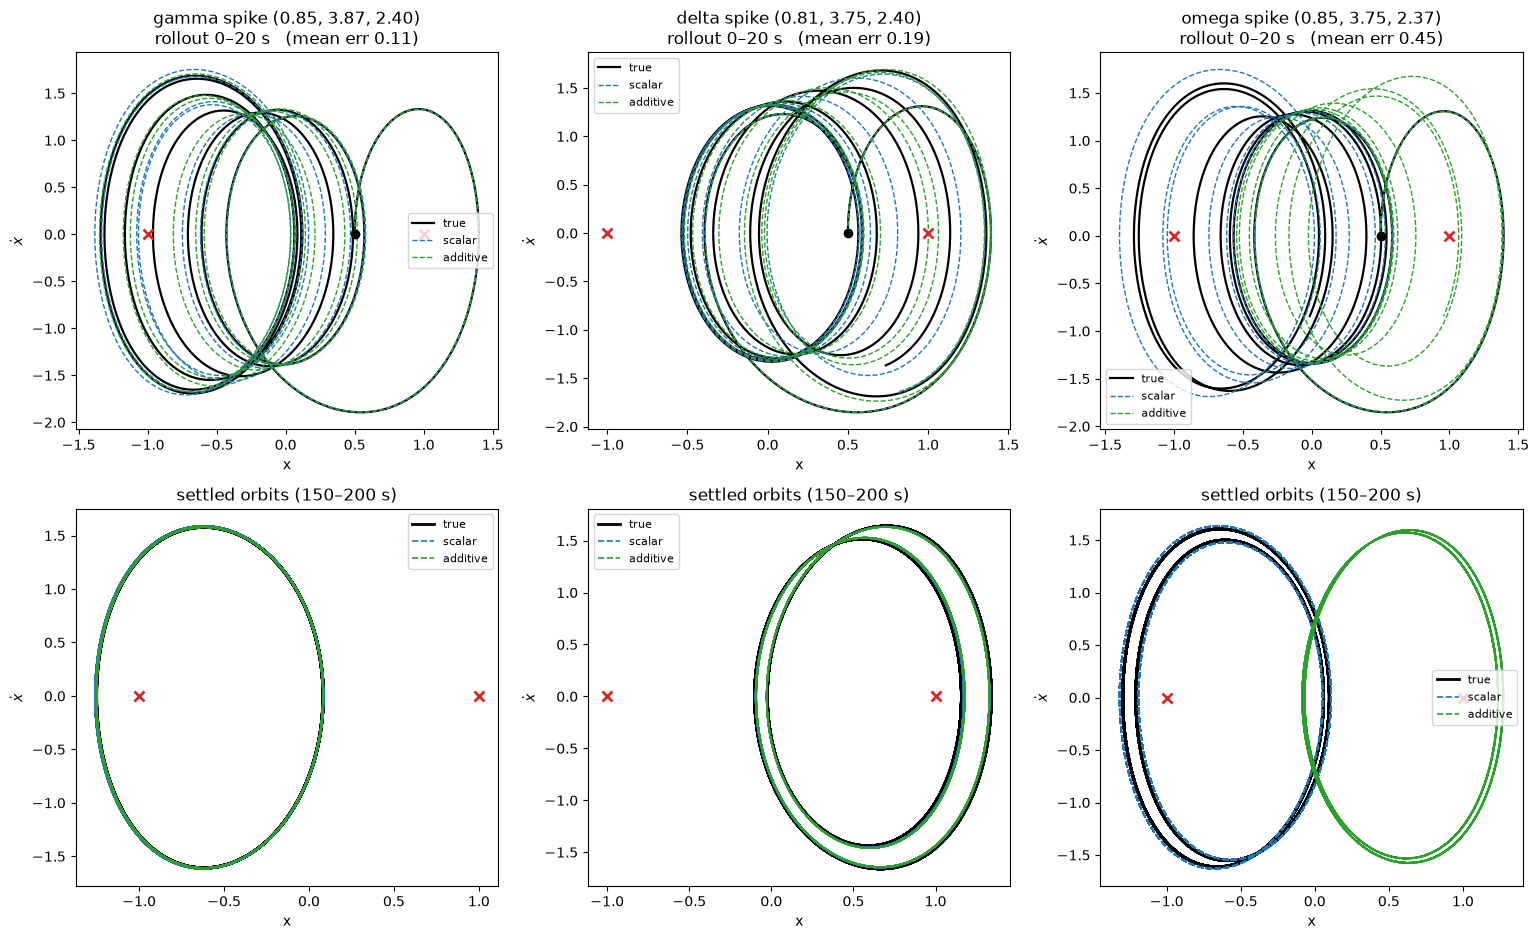

In [9]:
spike_pts = []
for pname, j, vals, _, _2 in RAYS:
    rd = ray_data[pname]
    inbox = (vals >= P_LO[j]) & (vals <= P_HI[j])
    worst = np.maximum(rd['scalar'][0], rd['additive'][0])
    k = np.where(inbox)[0][np.argmax(worst[inbox])]
    spike_pts.append((pname, rd['phs'][k], worst[k]))
    print(f'{pname:6s} spike: params ({rd["phs"][k][0]:.3f}, '
          f'{rd["phs"][k][1]:.3f}, {rd["phs"][k][2]:.3f})   '
          f'worst mean err {worst[k]:.2e}')

T_LONG = 200.0
N_LONG = int(round(T_LONG / DT_SAVE))
t_long = np.arange(N_LONG + 1) * DT_SAVE
settle = t_long > 150.0

fig, ax = plt.subplots(2, 3, figsize=(15.5, 9.5))
for col, (pname, ph, werr) in enumerate(spike_pts):
    phj = jnp.asarray(ph)
    tru20 = np.asarray(sim_true(jnp.array([0.5, 0.0]), phj, N_SAVE))
    truL = np.asarray(sim_true(jnp.array([0.5, 0.0]), phj, N_LONG))

    a = ax[0, col]
    a.plot(tru20[:, 0], tru20[:, 1], 'k', lw=1.6, label='true')
    for tag, rhs, p, color in MODELS:
        rol = np.asarray(simulate(lambda s, t: rhs(p, s, t, phj),
                                  jnp.array([0.5, 0.0]), 0.0,
                                  N_SAVE, DT_SAVE, 1))
        a.plot(rol[:, 0], rol[:, 1], '--', color=color, lw=1.0, label=tag)
    a.plot(0.5, 0.0, 'o', color='k', ms=6)
    a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=7, mew=2)
    a.set_title(f'{pname} spike ({ph[0]:.2f}, {ph[1]:.2f}, {ph[2]:.2f})'
                f'\nrollout 0–20 s   (mean err {werr:.2f})')
    a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
    a.legend(fontsize=8)

    a = ax[1, col]
    a.plot(truL[settle, 0], truL[settle, 1], 'k', lw=2.0, label='true')
    for tag, rhs, p, color in MODELS:
        rolL = np.asarray(simulate(lambda s, t: rhs(p, s, t, phj),
                                   jnp.array([0.5, 0.0]), 0.0,
                                   N_LONG, DT_SAVE, 1))
        a.plot(rolL[settle, 0], rolL[settle, 1], '--', color=color,
               lw=1.2, label=tag)
    a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=7, mew=2)
    a.set_title('settled orbits (150–200 s)')
    a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8 — The learned force laws, across the family

The additive model's term-by-term report card, now with parameter axes:

- $f_\theta(x)$ — one curve for the whole family, against $x - x^3$;
- $d_\theta(\dot{x}, \delta)$ at $\delta = 0.7, 0.85, 1.0$, against the lines
  $-\delta\dot{x}$ — is the learned surface linear in both arguments?
- $g_\theta$ over one drive cycle at three $(\gamma, \omega)$ combinations, against
  $\gamma\cos\omega t$ — and the $\omega$-independence check: same $\gamma$, two
  different $\omega$, plotted against phase $\theta = \omega t$; the truth is one
  curve, so any gap is $g$ using the redundant $\omega$ input.

Gauge: only a single global constant can shuttle between the three terms now
(a $\delta$-dependent offset in $d$ has nowhere to hide — nothing else takes
$\delta$), fixed by $d(0, 0.85) = 0$ and zero-mean $g$ at the reference
$(\gamma, \omega) = (3.75, 2.4)$, both absorbed into $f$.

gauge constants:  mean(g at ref) = +0.3616   d(0, 0.85) = -0.0142


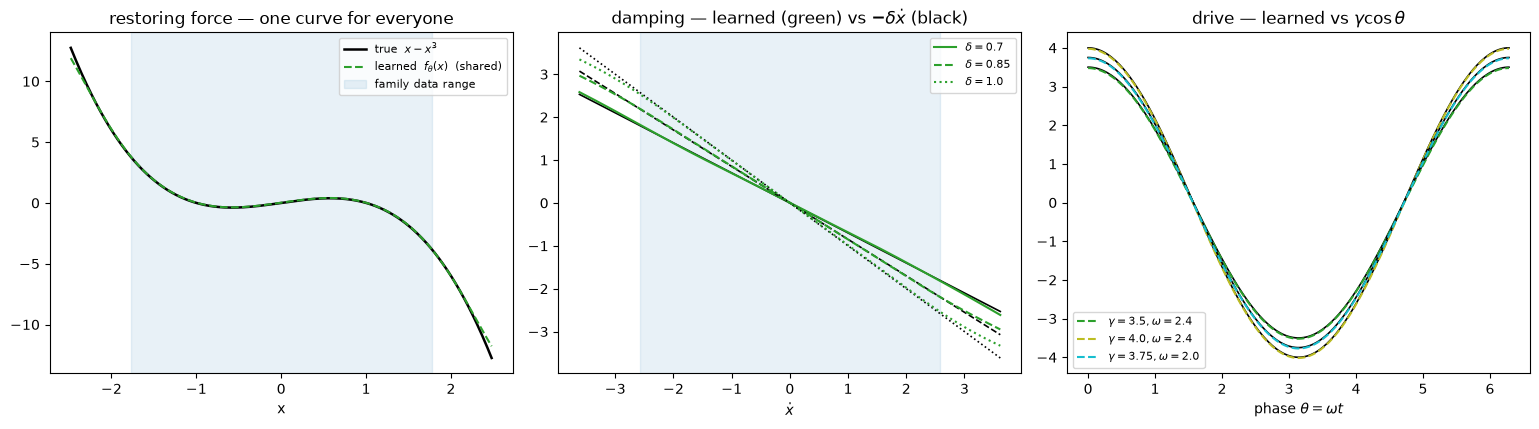

max |f error|  in family data range: 2.64e-02   at plot edges: 9.67e-01
max |d error|  delta=0.7: 2.14e-02
max |d error|  delta=0.85: 1.13e-02
max |d error|  delta=1.0: 4.45e-02
omega-independence of g: max |g(gamma=3.75, omega=2.0) - g(gamma=3.75, omega=2.8)| over a cycle = 5.88e-03   (truth: 0)


In [10]:
def d_term(v, delta):
    return additive_terms(params_a, jnp.array([0.0, v]), 0.0,
                          jnp.array([delta, 3.75, 2.4]))[1]

def g_term(t, gamma, omega):
    return additive_terms(params_a, jnp.array([0.0, 0.0]), t,
                          jnp.array([0.85, gamma, omega]))[2]

def f_term(x):
    return additive_terms(params_a, jnp.array([x, 0.0]), 0.0,
                          jnp.array([0.85, 3.75, 2.4]))[0]

th = np.linspace(0.0, 2 * np.pi, 200)
g_ref = np.asarray(jax.vmap(lambda t: g_term(t, 3.75, 2.4))(
    jnp.asarray(th / 2.4)))
c_g = g_ref.mean()
c_d = float(d_term(0.0, 0.85))
print(f'gauge constants:  mean(g at ref) = {c_g:+.4f}   d(0, 0.85) = {c_d:+.4f}')

XMAX = float(EXT[:, 0].max())
VMAX = float(EXT[:, 1].max())
x_plot = np.linspace(-1.4 * XMAX, 1.4 * XMAX, 400)
v_plot = np.linspace(-1.4 * VMAX, 1.4 * VMAX, 400)
f_vals = np.asarray(jax.vmap(f_term)(jnp.asarray(x_plot))) + c_g + c_d

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.4))
a = ax[0]
a.plot(x_plot, x_plot - x_plot**3, 'k', lw=1.8, label='true  $x - x^3$')
a.plot(x_plot, f_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $f_\theta(x)$  (shared)')
a.axvspan(-XMAX, XMAX, color='tab:blue', alpha=0.10, label='family data range')
a.set_xlabel('x'); a.set_title('restoring force — one curve for everyone')
a.legend(fontsize=8)

a = ax[1]
for delta, ls in [(0.7, '-'), (0.85, '--'), (1.0, ':')]:
    a.plot(v_plot, -delta * v_plot, 'k', lw=1.2, ls=ls)
    dv = np.asarray(jax.vmap(lambda v: d_term(v, delta))(
        jnp.asarray(v_plot))) - c_d
    a.plot(v_plot, dv, ls, color='tab:green', lw=1.5,
           label=f'$\\delta = {delta}$')
a.axvspan(-VMAX, VMAX, color='tab:blue', alpha=0.10)
a.set_xlabel(r'$\dot{x}$')
a.set_title(r'damping — learned (green) vs $-\delta\dot{x}$ (black)')
a.legend(fontsize=8)

a = ax[2]
for gamma, omega, color in [(3.5, 2.4, 'tab:green'), (4.0, 2.4, 'tab:olive'),
                            (3.75, 2.0, 'tab:cyan')]:
    a.plot(th, gamma * np.cos(th), 'k', lw=1.2)
    gv = np.asarray(jax.vmap(lambda t: g_term(t, gamma, omega))(
        jnp.asarray(th / omega))) - c_g
    a.plot(th, gv, '--', color=color, lw=1.5,
           label=f'$\\gamma={gamma}, \\omega={omega}$')
a.set_xlabel(r'phase $\theta = \omega t$')
a.set_title(r'drive — learned vs $\gamma\cos\theta$')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

in_x = np.abs(x_plot) <= XMAX
print(f'max |f error|  in family data range: '
      f'{np.abs(f_vals - (x_plot - x_plot**3))[in_x].max():.2e}'
      f'   at plot edges: '
      f'{np.abs(f_vals - (x_plot - x_plot**3))[[0, -1]].max():.2e}')
for delta in (0.7, 0.85, 1.0):
    dv = np.asarray(jax.vmap(lambda v: d_term(v, delta))(
        jnp.asarray(v_plot))) - c_d
    iv = np.abs(v_plot) <= VMAX
    print(f'max |d error|  delta={delta}: '
          f'{np.abs(dv + delta * v_plot)[iv].max():.2e}')
g_w1 = np.asarray(jax.vmap(lambda t: g_term(t, 3.75, 2.0))(
    jnp.asarray(th / 2.0)))
g_w2 = np.asarray(jax.vmap(lambda t: g_term(t, 3.75, 2.8))(
    jnp.asarray(th / 2.8)))
print(f'omega-independence of g: max |g(gamma=3.75, omega=2.0) - '
      f'g(gamma=3.75, omega=2.8)| over a cycle = {np.abs(g_w1 - g_w2).max():.2e}'
      f'   (truth: 0)')

## What this rung settles

1. **Family vs memorization**: Section 6 is the verdict — if unseen interior
   parameter draws roll out as well as trained ones, the model learned the *map*
   $(\text{state}, \text{phase}, \delta, \gamma, \omega) \to a$, not 48 oscillators.
2. **Parameter extrapolation**: the rays in Section 7 are the new frontier of the
   trust-region story. Prediction to falsify: the additive model degrades gently
   along $\delta$ (its damping term sees $\delta$ through what is nearly a linear
   law) and $\gamma$ (linear in the drive), while the scalar model — which must
   discover how each parameter threads through a 7-input black box — falls off
   faster outside the box.
3. **The force surfaces** (Section 8) are the mechanism check: a shared $f$, a
   $d$-plane linear in both $\dot{x}$ and $\delta$, a drive linear in $\gamma$ that
   ignores its redundant $\omega$ input — each one the family-level law recovered
   from data.

Natural next rungs: hold out the four historic parameter points and re-run the
Step 5/6 structure tests (period-8 table at never-trained parameters); the polynomial
skeleton for $f$, now buying extrapolation for the *entire family* at once; parameter
sweeps of the learned model to reproduce atlas slices (bifurcation diagrams from a
neural ODE).


---

# Part C — Step 9: 4.5× the data

Same box, 128 draws × 35 ICs = 9M pairs, 60k steps. The scaling scoreboard. Each part is self-contained (re-defines its own globals).

---


# Duffing Neural ODE — Step 9: the same family, 4.5× the data

Until now every model owned exactly one oscillator. This notebook feeds the physical
parameters to the network and learns the **map from $(x, \dot{x}, \text{phase},
\delta, \gamma, \omega)$ to acceleration** — one model for the entire Duffing family
over

$$\delta \in [0.7, 1.0], \qquad \gamma \in [3.5, 4.0], \qquad \omega \in [1.9, 2.9],$$

the same chaos-free box as Step 8, now at **4.5× the data**: 128 parameter draws
(λ-screened: 0/128 chaotic, λ ∈ [−0.49, −0.007]) × 35 ICs each (7×5 grid) × 20 s →
**~9M training pairs**, trained for 60k steps (lr drop at 40k). Everything else —
models, box, rays, spike autopsy — is identical to Step 8, so any change is
attributable to scale. The question: which of Step 8's imperfections does data
volume fix? Predictions: the smooth in-box error floor and the force-law residuals
should improve (they are fit quality); the bifurcation phase slips and the
mirror-twin basin call should NOT (they are properties of marginal stability, not of
fit accuracy); parameter extrapolation beyond the box should barely move (no data
was added out there).

Two models, matched to the Step 5–6 finalists but with the new inputs:

| model | acceleration | inputs | params |
|---|---|---|---|
| **scalar** | one MLP, 1 output | $(x, \dot{x}, \cos\omega t, \sin\omega t, \delta, \gamma, \omega)$ flat | ~4.7k |
| **additive** | $f_\theta(x) + d_\theta(\dot{x}, \delta) + g_\theta(\cos\omega t, \sin\omega t, \gamma, \omega)$ | routed | ~3.6k |

The additive routing now encodes *parameter* physics on top of the force split:
$f$ takes **no parameters** (the restoring force is shared by the whole family — and
gets trained by every trajectory of every oscillator), $\delta$ can only touch the
damping term, and $\gamma, \omega$ can only touch the drive. Two claims the truth
satisfies ($f = x - x^3$ for everyone; $d = -\delta\dot{x}$; $g = \gamma\cos\omega t$)
and the black box has to discover on its own. One deliberate redundancy: $g$ receives
$\omega$ even though the phase pair already encodes it — whether $g$ *learns to ignore
$\omega$* becomes an evaluation.



In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

P_LO = np.array([0.7, 3.5, 1.9])   # delta, gamma, omega
P_HI = np.array([1.0, 4.0, 2.9])
N_SETS = 128
N_EVAL_SETS = 12

def true_rhs(s, t, ph):
    x, v = s
    delta, gamma, omega = ph
    return jnp.array([v, -delta * v + x - x**3 + gamma * jnp.cos(omega * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

DT_INT, DT_SAVE = 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))

def sim_true(s0, ph, n_save, substeps=SUBS):
    return simulate(lambda s, t: true_rhs(s, t, ph), jnp.asarray(s0), 0.0,
                    n_save, DT_SAVE, substeps)

def lhs_box(n, lo, hi, rng):
    out = np.empty((n, len(lo)))
    for j in range(len(lo)):
        out[:, j] = lo[j] + (hi[j] - lo[j]) * \
            (rng.permutation(n) + rng.uniform(size=n)) / n
    return out

rng = np.random.default_rng(42)
PARAM_SETS = lhs_box(N_SETS, P_LO, P_HI, rng)
print('128 training parameter sets (Latin hypercube), first 5:')
for ph in PARAM_SETS[:5]:
    print(f'   delta={ph[0]:.3f}  gamma={ph[1]:.3f}  omega={ph[2]:.3f}')

128 training parameter sets (Latin hypercube), first 5:
   delta=0.779  gamma=3.909  omega=2.383
   delta=0.705  gamma=3.765  omega=2.543
   delta=0.789  gamma=3.838  omega=2.492
   delta=0.932  gamma=3.644  omega=2.084
   delta=0.849  gamma=3.516  omega=2.065


## 1 — Training data: 48 oscillators × 21 ICs

For each parameter set: a 120 s pre-sim measures that oscillator's attractor extent,
the 7×3 IC grid is scaled to 80% of it, and 21 trajectories of 20 s are generated.
Chaotic parameter draws are welcome — one-step training only needs the vector field
sampled broadly, not tidy orbits.

In [2]:
T_PRE = 120.0
N_PRE = int(round(T_PRE / DT_SAVE))
pre = np.asarray(jax.vmap(
    lambda ph: sim_true(jnp.array([0.5, 0.0]), ph, N_PRE))(
        jnp.asarray(PARAM_SETS)))
tail = pre[:, int(40.0 / DT_SAVE):, :]
EXT = np.abs(tail).max(axis=1)           # (48, 2)
BOX = np.round(0.8 * EXT, 1)
print('attractor extent across the family:')
print(f'   |x|: min {EXT[:, 0].min():.2f}  max {EXT[:, 0].max():.2f}')
print(f'   |v|: min {EXT[:, 1].min():.2f}  max {EXT[:, 1].max():.2f}')

N_IC_X, N_IC_V = 7, 5
N_ICS = N_IC_X * N_IC_V
T_END = 20.0
N_SAVE = int(round(T_END / DT_SAVE))
times = np.arange(N_SAVE + 1) * DT_SAVE

ic_all, ph_all = [], []
for k in range(N_SETS):
    g = np.stack(np.meshgrid(np.linspace(-BOX[k, 0], BOX[k, 0], N_IC_X),
                             np.linspace(-BOX[k, 1], BOX[k, 1], N_IC_V),
                             indexing='ij'), axis=-1).reshape(-1, 2)
    ic_all.append(g)
    ph_all.append(np.repeat(PARAM_SETS[k][None], N_ICS, axis=0))
ic_all = np.concatenate(ic_all)          # (1008, 2)
ph_all = np.concatenate(ph_all)          # (1008, 3)

trajs = np.asarray(jax.vmap(lambda s0, ph: sim_true(s0, ph, N_SAVE))(
    jnp.asarray(ic_all), jnp.asarray(ph_all)))
print('training trajectories:', trajs.shape)

s_now = jnp.asarray(trajs[:, :-1, :].reshape(-1, 2))
s_next = jnp.asarray(trajs[:, 1:, :].reshape(-1, 2))
t_now = jnp.asarray(np.tile(times[:-1], len(ic_all)))
p_now = jnp.asarray(np.repeat(ph_all, N_SAVE, axis=0))
N_PAIRS = s_now.shape[0]
print(f'training pairs: {N_PAIRS:,}')

attractor extent across the family:
   |x|: min 0.83  max 1.72
   |v|: min 1.38  max 2.56


training trajectories: (4480, 2001, 2)
training pairs: 8,960,000


## 2 — The two models

In [3]:
def init_mlp(key, layers):
    params = []
    for n_in, n_out in zip(layers[:-1], layers[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def mlp(params, u):
    h = u
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

LAYERS_SCALAR = [7, 64, 64, 1]
def init_scalar(key):
    return init_mlp(key, LAYERS_SCALAR)
def rhs_scalar(params, s, t, ph):
    delta, gamma, omega = ph
    u = jnp.array([s[0], s[1], jnp.cos(omega * t), jnp.sin(omega * t),
                   delta, gamma, omega])
    return jnp.array([s[1], mlp(params, u)[0]])

F_LAYERS = [1, 32, 32, 1]
D_LAYERS = [2, 32, 32, 1]
G_LAYERS = [4, 32, 32, 1]
N_F, N_D = len(F_LAYERS) - 1, len(D_LAYERS) - 1

def init_additive(key):
    kf, kd, kg = jax.random.split(key, 3)
    return (init_mlp(kf, F_LAYERS) + init_mlp(kd, D_LAYERS)
            + init_mlp(kg, G_LAYERS))

def additive_terms(params, s, t, ph):
    delta, gamma, omega = ph
    pf = params[:N_F]
    pd = params[N_F:N_F + N_D]
    pg = params[N_F + N_D:]
    f = mlp(pf, jnp.array([s[0]]))[0]
    d = mlp(pd, jnp.array([s[1], delta]))[0]
    g = mlp(pg, jnp.array([jnp.cos(omega * t), jnp.sin(omega * t),
                           gamma, omega]))[0]
    return f, d, g

def rhs_additive(params, s, t, ph):
    f, d, g = additive_terms(params, s, t, ph)
    return jnp.array([s[1], f + d + g])

for name, init in [('scalar', init_scalar), ('additive', init_additive)]:
    n = sum(W.size + b.size for W, b in init(jax.random.PRNGKey(0)))
    print(f'{name:9s} parameters: {n}')

scalar    parameters: 4737


additive  parameters: 3587


## 3 — Training

Same one-step harness, scaled up: 30k Adam steps (lr 1e-3 → 1e-4 at 20k), batch
16,384 drawn from the 2M-pair pool. The tracked loss is on a fixed 131k-pair random
subset (evaluating all 2M every 500 steps would dominate the run). Caches
`params_family_<model>.npz` — delete to retrain.

In [4]:
import os

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

BATCH = 16384
N_STEPS = 60000
LR_DROP = 40000
EVAL_EVERY = 500
EVAL_IDX = jnp.asarray(np.random.default_rng(3).choice(N_PAIRS, 131072,
                                                       replace=False))

def train(rhs, init_fn, model_tag):
    def one_step(params, s, t, ph):
        return rk4_step(lambda s_, t_: rhs(params, s_, t_, ph), s, t, DT_SAVE)

    def loss_on(params, sb, snb, tb, pb):
        pred = jax.vmap(lambda s, t, ph: one_step(params, s, t, ph))(sb, tb, pb)
        return jnp.mean((pred - snb) ** 2)

    eval_loss = jax.jit(lambda p: loss_on(p, s_now[EVAL_IDX], s_next[EVAL_IDX],
                                          t_now[EVAL_IDX], p_now[EVAL_IDX]))

    cache = f'params_family3_{model_tag}.npz'
    if os.path.exists(cache):
        z = np.load(cache)
        n_layers = sum(1 for k in z.files if k.startswith('W'))
        params = [(jnp.asarray(z[f'W{i}']), jnp.asarray(z[f'b{i}']))
                  for i in range(n_layers)]
        print(f'[{model_tag}] loaded cached params from {cache}   '
              f'eval loss {float(eval_loss(params)):.3e}   '
              f'(delete the file to retrain)')
        return (params, z['hist_steps'], z['hist_loss'], float(z['wall']))

    @jax.jit
    def train_step(params, m, v, step, lr, key):
        idx = jax.random.randint(key, (BATCH,), 0, N_PAIRS)
        loss, grads = jax.value_and_grad(loss_on)(
            params, s_now[idx], s_next[idx], t_now[idx], p_now[idx])
        params, m, v = adam_update(params, grads, m, v, step, lr)
        return params, m, v, loss

    params = init_fn(jax.random.PRNGKey(0))
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    base_key = jax.random.PRNGKey(1)

    hist_steps, hist_loss = [], []
    t0 = time.time()
    for i in range(1, N_STEPS + 1):
        lr = 1e-3 if i <= LR_DROP else 1e-4
        params, m, v, _ = train_step(params, m, v, float(i), lr,
                                     jax.random.fold_in(base_key, i))
        if i == 1 or i % EVAL_EVERY == 0:
            fl = float(eval_loss(params))
            hist_steps.append(i)
            hist_loss.append(fl)
            if i == 1 or i % 5000 == 0:
                print(f'[{model_tag}] step {i:6d}   lr {lr:.0e}'
                      f'   eval loss {fl:.3e}')
    wall = time.time() - t0
    print(f'[{model_tag}] final eval loss {hist_loss[-1]:.3e}'
          f'   wall time {wall:.0f} s')
    np.savez(cache, hist_steps=np.array(hist_steps),
             hist_loss=np.array(hist_loss), wall=wall,
             **{f'W{i}': np.asarray(Wt) for i, (Wt, _) in enumerate(params)},
             **{f'b{i}': np.asarray(bt) for i, (_, bt) in enumerate(params)})
    return params, np.array(hist_steps), np.array(hist_loss), wall

params_s, steps_s, loss_s, wall_s = train(rhs_scalar, init_scalar, 'scalar')
params_a, steps_a, loss_a, wall_a = train(rhs_additive, init_additive,
                                          'additive')

MODELS = [('scalar', rhs_scalar, params_s, 'tab:blue'),
          ('additive', rhs_additive, params_a, 'tab:green')]

[scalar] step      1   lr 1e-03   eval loss 3.464e-04


[scalar] step   5000   lr 1e-03   eval loss 5.778e-08


[scalar] step  10000   lr 1e-03   eval loss 2.022e-08


[scalar] step  15000   lr 1e-03   eval loss 1.595e-08


[scalar] step  20000   lr 1e-03   eval loss 7.136e-09


...

[additive] step  40000   lr 1e-03   eval loss 3.701e-09


[additive] step  45000   lr 1e-04   eval loss 1.984e-09


[additive] step  50000   lr 1e-04   eval loss 1.900e-09


[additive] step  55000   lr 1e-04   eval loss 1.666e-09


[additive] step  60000   lr 1e-04   eval loss 1.495e-09
[additive] final eval loss 1.495e-09   wall time 906 s


## 4 — Learning curves

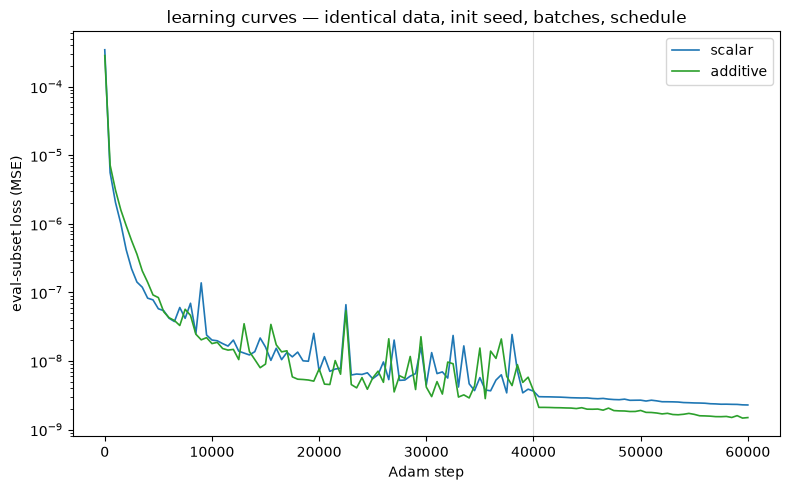

final loss   scalar 2.284e-09   additive 1.495e-09
wall time    scalar 692 s   additive 906 s


In [5]:
fig, a = plt.subplots(figsize=(8, 5))
for (tag, _, _, color), st, lo in [(MODELS[0], steps_s, loss_s),
                                   (MODELS[1], steps_a, loss_a)]:
    a.semilogy(st, lo, color=color, lw=1.2, label=tag)
a.axvline(LR_DROP, color='0.85', lw=0.8, zorder=0)
a.set_xlabel('Adam step')
a.set_ylabel('eval-subset loss (MSE)')
a.set_title('learning curves — identical data, init seed, batches, schedule')
a.legend()
plt.tight_layout(); plt.show()

print(f'final loss   scalar {loss_s[-1]:.3e}   additive {loss_a[-1]:.3e}')
print(f'wall time    scalar {wall_s:.0f} s   additive {wall_a:.0f} s')

## 5 — One-step errors and held-out ICs at trained parameters

One-step error over all 2M pairs (chunked), then 20 s rollouts from held-out interior
ICs at four of the 48 trained parameter sets — the easiest ask: same oscillators,
new starts.

In [6]:
def one_step_errors(rhs, params):
    f = jax.jit(jax.vmap(lambda s, t, ph: rk4_step(
        lambda s_, t_: rhs(params, s_, t_, ph), s, t, DT_SAVE)))
    errs = []
    CH = 262144
    for i in range(0, N_PAIRS, CH):
        pred = f(s_now[i:i + CH], t_now[i:i + CH], p_now[i:i + CH])
        errs.append(np.asarray(
            jnp.linalg.norm(pred - s_next[i:i + CH], axis=1)))
    return np.concatenate(errs)

for tag, rhs, p, _ in MODELS:
    e = one_step_errors(rhs, p)
    print(f'{tag:9s} one-step error   median {np.median(e):.2e}'
          f'   mean {e.mean():.2e}   max {e.max():.2e}')

LOCK_ERR = 1.0
lock_win = times[:-1] >= T_END - 5.0

def rollout_err(rhs, params, ic, ph):
    tru = np.asarray(sim_true(ic, jnp.asarray(ph), N_SAVE))
    rol = np.asarray(simulate(lambda s, t: rhs(params, s, t, jnp.asarray(ph)),
                              jnp.asarray(ic), 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    return err.mean(), err[:-1][lock_win].mean() < LOCK_ERR

FRACS = [(0.44, 0.42), (-0.81, -0.72), (0.93, 0.87)]
SHOW_SETS = [0, 13, 27, 41]
print()
print('held-out ICs at trained parameter sets (mean rollout error, 20 s):')
print(f'{"params (d, g, w)":>26s} {"IC":>15s} {"scalar":>11s} {"additive":>11s}'
      '   locked?')
for k in SHOW_SETS:
    ph = PARAM_SETS[k]
    for fx, fv in FRACS:
        ic = (round(fx * BOX[k, 0], 2), round(fv * BOX[k, 1], 2))
        row, locks = [], []
        for tag, rhs, p, _ in MODELS:
            e, l = rollout_err(rhs, p, jnp.array(ic), ph)
            row.append(e)
            locks.append(l)
        lab = f'({ph[0]:.2f}, {ph[1]:.2f}, {ph[2]:.2f})'
        print(f'{lab:>26s} {str(ic):>15s} {row[0]:>11.2e} {row[1]:>11.2e}'
              f'   {locks[0]} / {locks[1]}')

scalar    one-step error   median 2.72e-05   mean 4.07e-05   max 4.80e-03


additive  one-step error   median 2.94e-05   mean 3.68e-05   max 5.69e-03

held-out ICs at trained parameter sets (mean rollout error, 20 s):
          params (d, g, w)              IC      scalar    additive   locked?


        (0.78, 3.91, 2.38) (np.float64(0.44), np.float64(0.55))    6.96e-02    1.01e-01   True / True


        (0.78, 3.91, 2.38) (np.float64(-0.81), np.float64(-0.94))    6.42e-03    4.39e-03   True / True


        (0.78, 3.91, 2.38) (np.float64(0.93), np.float64(1.13))    1.50e-02    8.03e-03   True / True


...

        (0.74, 3.89, 2.13) (np.float64(-0.73), np.float64(-0.94))    1.48e-02    6.00e-03   True / True


        (0.74, 3.89, 2.13) (np.float64(0.84), np.float64(1.13))    2.79e-03    1.10e-03   True / True


        (0.87, 3.93, 2.30) (np.float64(0.44), np.float64(0.55))    2.61e-03    1.97e-02   True / True


        (0.87, 3.93, 2.30) (np.float64(-0.81), np.float64(-0.94))    1.01e-02    1.94e-02   True / True


        (0.87, 3.93, 2.30) (np.float64(0.93), np.float64(1.13))    1.94e-02    7.22e-03   True / True


## 6 — Parameter interpolation: 12 unseen parameter draws

The new dimension's core test. Twelve fresh Latin-hypercube draws from the *same box*
— oscillators the models have never seen — three held-out ICs each (scaled to each
oscillator's own measured extent). If the models learned the family and not 48
oscillators, these numbers should look like Section 5's.

In [7]:
EVAL_SETS = lhs_box(N_EVAL_SETS, P_LO, P_HI, np.random.default_rng(7))
pre_e = np.asarray(jax.vmap(
    lambda ph: sim_true(jnp.array([0.5, 0.0]), ph, N_PRE))(
        jnp.asarray(EVAL_SETS)))
EXT_E = np.abs(pre_e[:, int(40.0 / DT_SAVE):, :]).max(axis=1)

print('unseen interior parameter draws (mean rollout error, 20 s):')
print(f'{"params (d, g, w)":>26s} {"IC":>15s} {"scalar":>11s} {"additive":>11s}'
      '   locked?')
all_err = {tag: [] for tag, *_ in MODELS}
for k in range(N_EVAL_SETS):
    ph = EVAL_SETS[k]
    lims = 0.8 * EXT_E[k]
    for fx, fv in FRACS:
        ic = (round(fx * lims[0], 2), round(fv * lims[1], 2))
        row, locks = [], []
        for tag, rhs, p, _ in MODELS:
            e, l = rollout_err(rhs, p, jnp.array(ic), ph)
            row.append(e)
            locks.append(l)
            all_err[tag].append(e)
        lab = f'({ph[0]:.2f}, {ph[1]:.2f}, {ph[2]:.2f})'
        print(f'{lab:>26s} {str(ic):>15s} {row[0]:>11.2e} {row[1]:>11.2e}'
              f'   {locks[0]} / {locks[1]}')
print()
for tag, *_ in MODELS:
    e = np.array(all_err[tag])
    print(f'{tag:9s} over all 36 unseen-param rollouts:'
          f'   median {np.median(e):.2e}   mean {e.mean():.2e}'
          f'   max {e.max():.2e}')

unseen interior parameter draws (mean rollout error, 20 s):
          params (d, g, w)              IC      scalar    additive   locked?


        (0.82, 3.69, 2.24) (np.float64(0.44), np.float64(0.54))    8.97e-03    2.42e-02   True / True


        (0.82, 3.69, 2.24) (np.float64(-0.8), np.float64(-0.92))    1.09e-02    9.12e-03   True / True


        (0.82, 3.69, 2.24) (np.float64(0.92), np.float64(1.12))    3.39e-02    4.55e-02   True / True


        (0.87, 3.54, 2.20) (np.float64(0.44), np.float64(0.53))    4.20e-02    3.24e-02   True / True


...

        (0.94, 3.89, 2.38) (np.float64(-0.82), np.float64(-0.93))    4.29e-02    3.16e-02   True / True


        (0.94, 3.89, 2.38) (np.float64(0.94), np.float64(1.12))    3.44e-02    2.43e-02   True / True


        (0.99, 3.63, 2.68) (np.float64(0.46), np.float64(0.49))    4.48e-03    2.90e-03   True / True


        (0.99, 3.63, 2.68) (np.float64(-0.84), np.float64(-0.83))    1.52e-02    1.71e-02   True / True


        (0.99, 3.63, 2.68) (np.float64(0.97), np.float64(1.0))    1.24e-02    8.63e-03   True / True

scalar    over all 36 unseen-param rollouts:   median 1.67e-02   mean 2.61e-02   max 1.26e-01
additive  over all 36 unseen-param rollouts:   median 1.30e-02   mean 1.52e-02   max 4.55e-02


## 7 — Parameter-extrapolation rays

The parameter-space analog of the IC rays: fix the IC at $(0.5, 0)$ and march one
parameter through and past the training box (red dashed = box edges; rug ticks =
the 48 training values of that parameter). Held-out center values for the other two
parameters. Where does the family model stop being trustworthy in *parameter* space?

gamma  ray  scalar    median err 4.48e-02   lost-lock: 0/61


gamma  ray  additive  median err 3.63e-02   lost-lock: 0/61


delta  ray  scalar    median err 2.68e-02   lost-lock: 8/61


delta  ray  additive  median err 6.25e-02   lost-lock: 6/61


omega  ray  scalar    median err 9.40e-03   lost-lock: 0/61


omega  ray  additive  median err 9.43e-03   lost-lock: 0/61


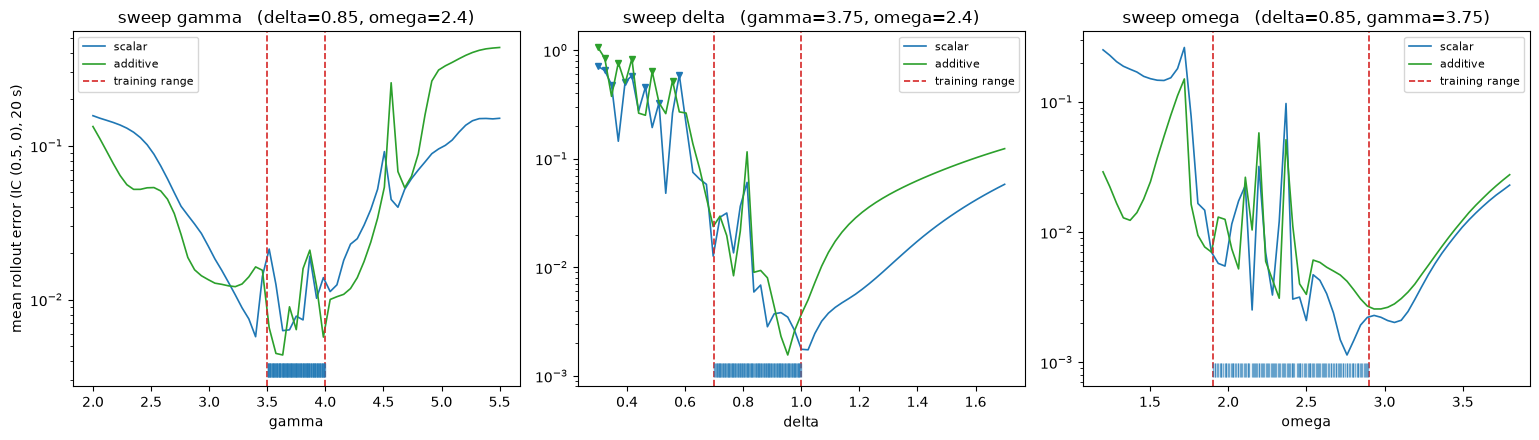

In [8]:
RAYS = [
    ('gamma', 1, np.linspace(2.0, 5.5, 61), None, None),
    ('delta', 0, np.linspace(0.3, 1.7, 61), None, None),
    ('omega', 2, np.linspace(1.2, 3.8, 61), None, None),
]
CENTER = {'delta': 0.85, 'gamma': 3.75, 'omega': 2.4}

ray_data = {}
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.5))
for a, (pname, j, vals, _, _2) in zip(ax, RAYS):
    phs = np.tile([CENTER['delta'], CENTER['gamma'], CENTER['omega']],
                  (len(vals), 1))
    phs[:, j] = vals
    tru = np.asarray(jax.vmap(
        lambda ph: sim_true(jnp.array([0.5, 0.0]), ph, N_SAVE))(
            jnp.asarray(phs)))
    ray_data[pname] = {'j': j, 'vals': vals, 'phs': phs}
    for tag, rhs, p, color in MODELS:
        rol = np.asarray(jax.vmap(
            lambda ph: simulate(lambda s, t: rhs(p, s, t, ph),
                                jnp.array([0.5, 0.0]), 0.0,
                                N_SAVE, DT_SAVE, 1))(jnp.asarray(phs)))
        err = np.linalg.norm(rol - tru, axis=2)
        mean_err = err.mean(axis=1)
        lost = err[:, :-1][:, lock_win].mean(axis=1) > LOCK_ERR
        ray_data[pname][tag] = (mean_err, lost)
        a.semilogy(vals, mean_err, color=color, lw=1.2, label=tag)
        a.semilogy(vals[lost], mean_err[lost], 'v', color=color, ms=5)
        print(f'{pname:6s} ray  {tag:9s} median err '
              f'{np.median(mean_err):.2e}   lost-lock: '
              f'{int(lost.sum())}/{len(vals)}')
    lo, hi = P_LO[j], P_HI[j]
    a.axvline(lo, color='tab:red', lw=1.2, ls='--')
    a.axvline(hi, color='tab:red', lw=1.2, ls='--', label='training range')
    a.plot(PARAM_SETS[:, j], np.full(N_SETS, a.get_ylim()[0]), '|',
           color='tab:blue', ms=10, alpha=0.6)
    others = [f'{n}={CENTER[n]}' for n in ('delta', 'gamma', 'omega')
              if n != pname]
    a.set_xlabel(pname)
    a.set_title(f'sweep {pname}   ({", ".join(others)})')
    a.legend(fontsize=8)
ax[0].set_ylabel('mean rollout error (IC (0.5, 0), 20 s)')
plt.tight_layout(); plt.show()

### 7b — Inside the spikes: what the models actually do there

For each ray, take the worst in-box parameter point and look at it directly. Top row:
the 20 s rollout from IC $(0.5, 0)$ that the error metric scored — truth in black,
models dashed. Bottom row: the long-run test — everyone runs 200 s and we overlay the
final 50 s (the settled orbits). If a spike is a *phase slip* or a *wrong-attractor
pick*, the bottom panel shows the learned orbit lying on (or mirroring) the true one
even though the top panel disagrees; if a model has genuinely wrong dynamics, its
settled orbit has the wrong shape entirely.

gamma  spike: params (0.850, 3.517, 2.400)   worst mean err 2.13e-02
delta  spike: params (0.813, 3.750, 2.400)   worst mean err 1.16e-01
omega  spike: params (0.850, 3.750, 2.370)   worst mean err 9.70e-02


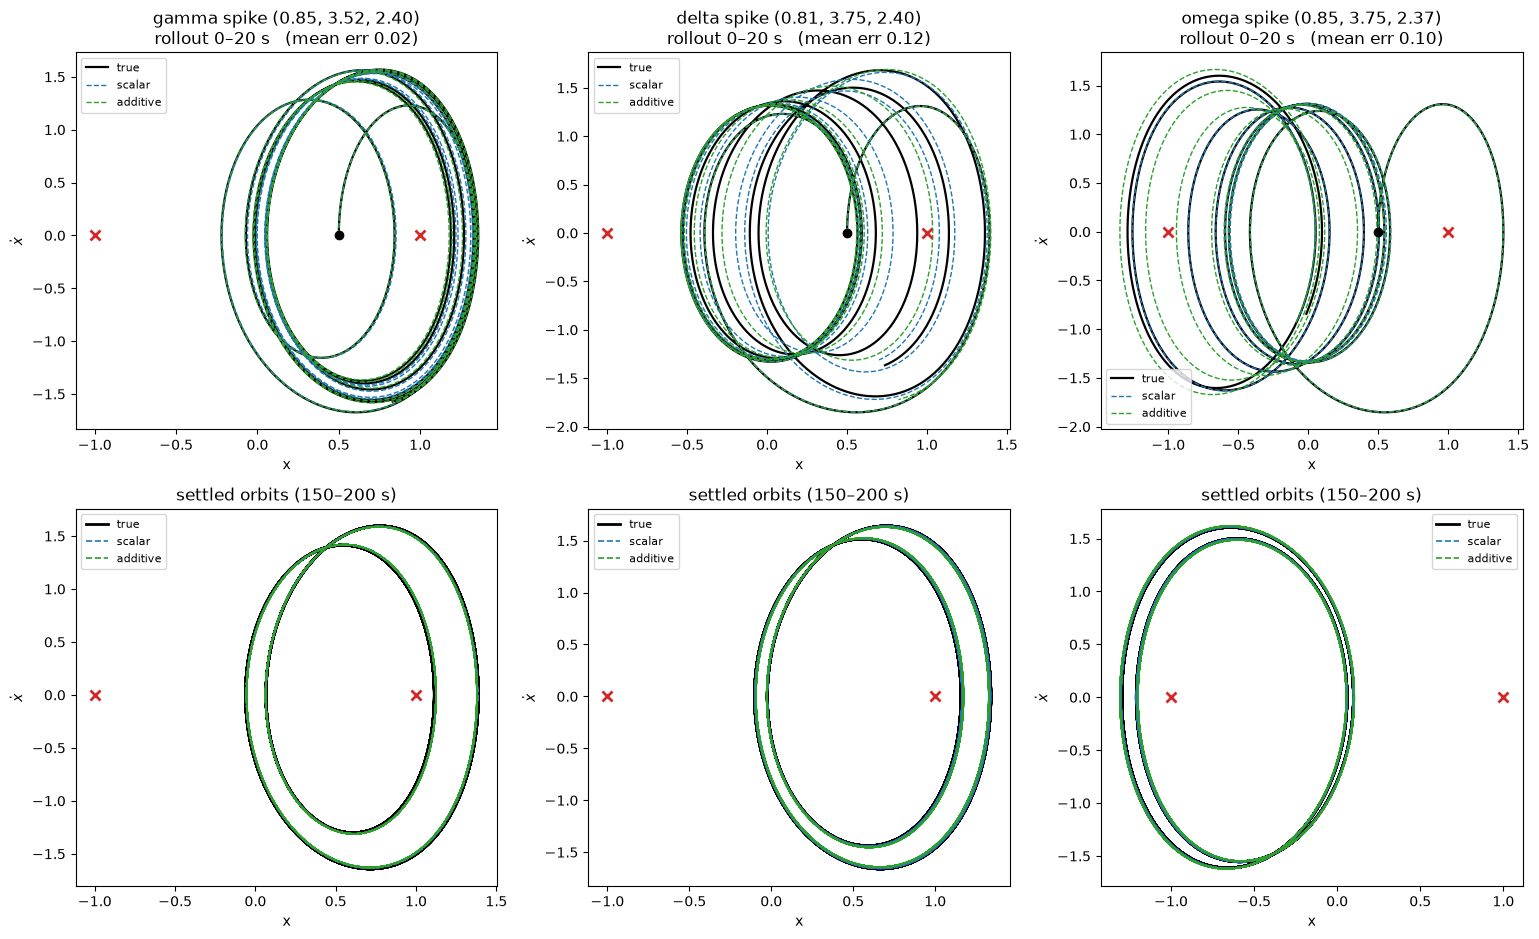

In [9]:
spike_pts = []
for pname, j, vals, _, _2 in RAYS:
    rd = ray_data[pname]
    inbox = (vals >= P_LO[j]) & (vals <= P_HI[j])
    worst = np.maximum(rd['scalar'][0], rd['additive'][0])
    k = np.where(inbox)[0][np.argmax(worst[inbox])]
    spike_pts.append((pname, rd['phs'][k], worst[k]))
    print(f'{pname:6s} spike: params ({rd["phs"][k][0]:.3f}, '
          f'{rd["phs"][k][1]:.3f}, {rd["phs"][k][2]:.3f})   '
          f'worst mean err {worst[k]:.2e}')

T_LONG = 200.0
N_LONG = int(round(T_LONG / DT_SAVE))
t_long = np.arange(N_LONG + 1) * DT_SAVE
settle = t_long > 150.0

fig, ax = plt.subplots(2, 3, figsize=(15.5, 9.5))
for col, (pname, ph, werr) in enumerate(spike_pts):
    phj = jnp.asarray(ph)
    tru20 = np.asarray(sim_true(jnp.array([0.5, 0.0]), phj, N_SAVE))
    truL = np.asarray(sim_true(jnp.array([0.5, 0.0]), phj, N_LONG))

    a = ax[0, col]
    a.plot(tru20[:, 0], tru20[:, 1], 'k', lw=1.6, label='true')
    for tag, rhs, p, color in MODELS:
        rol = np.asarray(simulate(lambda s, t: rhs(p, s, t, phj),
                                  jnp.array([0.5, 0.0]), 0.0,
                                  N_SAVE, DT_SAVE, 1))
        a.plot(rol[:, 0], rol[:, 1], '--', color=color, lw=1.0, label=tag)
    a.plot(0.5, 0.0, 'o', color='k', ms=6)
    a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=7, mew=2)
    a.set_title(f'{pname} spike ({ph[0]:.2f}, {ph[1]:.2f}, {ph[2]:.2f})'
                f'\nrollout 0–20 s   (mean err {werr:.2f})')
    a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
    a.legend(fontsize=8)

    a = ax[1, col]
    a.plot(truL[settle, 0], truL[settle, 1], 'k', lw=2.0, label='true')
    for tag, rhs, p, color in MODELS:
        rolL = np.asarray(simulate(lambda s, t: rhs(p, s, t, phj),
                                   jnp.array([0.5, 0.0]), 0.0,
                                   N_LONG, DT_SAVE, 1))
        a.plot(rolL[settle, 0], rolL[settle, 1], '--', color=color,
               lw=1.2, label=tag)
    a.plot([-1, 1], [0, 0], 'x', color='tab:red', ms=7, mew=2)
    a.set_title('settled orbits (150–200 s)')
    a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8 — The learned force laws, across the family

The additive model's term-by-term report card, now with parameter axes:

- $f_\theta(x)$ — one curve for the whole family, against $x - x^3$;
- $d_\theta(\dot{x}, \delta)$ at $\delta = 0.7, 0.85, 1.0$, against the lines
  $-\delta\dot{x}$ — is the learned surface linear in both arguments?
- $g_\theta$ over one drive cycle at three $(\gamma, \omega)$ combinations, against
  $\gamma\cos\omega t$ — and the $\omega$-independence check: same $\gamma$, two
  different $\omega$, plotted against phase $\theta = \omega t$; the truth is one
  curve, so any gap is $g$ using the redundant $\omega$ input.

Gauge: only a single global constant can shuttle between the three terms now
(a $\delta$-dependent offset in $d$ has nowhere to hide — nothing else takes
$\delta$), fixed by $d(0, 0.85) = 0$ and zero-mean $g$ at the reference
$(\gamma, \omega) = (3.75, 2.4)$, both absorbed into $f$.

gauge constants:  mean(g at ref) = +0.0863   d(0, 0.85) = +0.0710


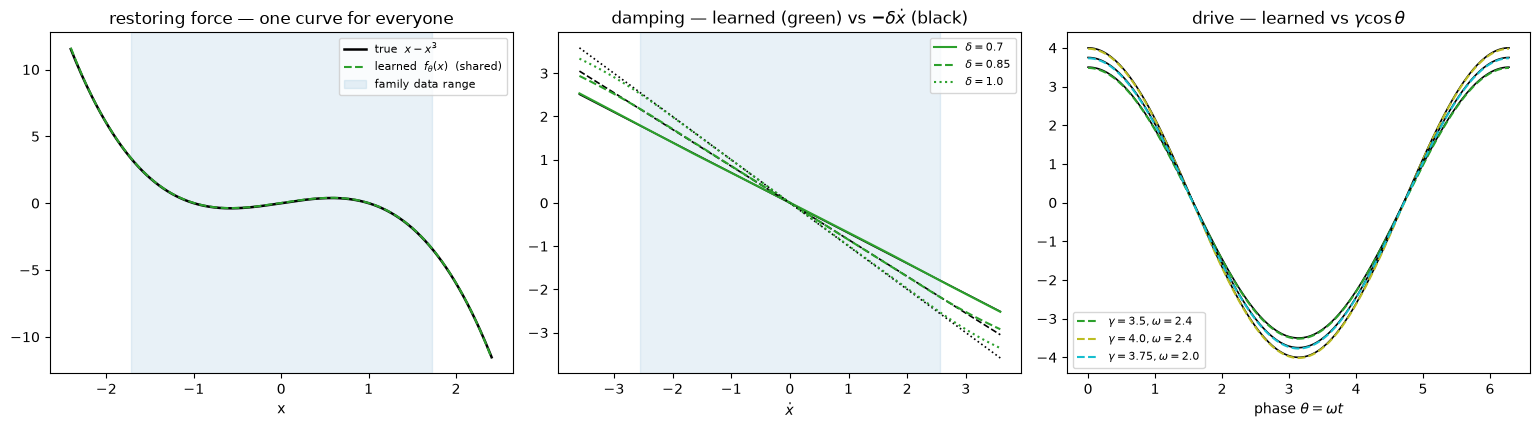

max |f error|  in family data range: 1.93e-02   at plot edges: 9.16e-02
max |d error|  delta=0.7: 1.46e-02
max |d error|  delta=0.85: 1.09e-02
max |d error|  delta=1.0: 2.96e-02
omega-independence of g: max |g(gamma=3.75, omega=2.0) - g(gamma=3.75, omega=2.8)| over a cycle = 3.97e-03   (truth: 0)


In [10]:
def d_term(v, delta):
    return additive_terms(params_a, jnp.array([0.0, v]), 0.0,
                          jnp.array([delta, 3.75, 2.4]))[1]

def g_term(t, gamma, omega):
    return additive_terms(params_a, jnp.array([0.0, 0.0]), t,
                          jnp.array([0.85, gamma, omega]))[2]

def f_term(x):
    return additive_terms(params_a, jnp.array([x, 0.0]), 0.0,
                          jnp.array([0.85, 3.75, 2.4]))[0]

th = np.linspace(0.0, 2 * np.pi, 200)
g_ref = np.asarray(jax.vmap(lambda t: g_term(t, 3.75, 2.4))(
    jnp.asarray(th / 2.4)))
c_g = g_ref.mean()
c_d = float(d_term(0.0, 0.85))
print(f'gauge constants:  mean(g at ref) = {c_g:+.4f}   d(0, 0.85) = {c_d:+.4f}')

XMAX = float(EXT[:, 0].max())
VMAX = float(EXT[:, 1].max())
x_plot = np.linspace(-1.4 * XMAX, 1.4 * XMAX, 400)
v_plot = np.linspace(-1.4 * VMAX, 1.4 * VMAX, 400)
f_vals = np.asarray(jax.vmap(f_term)(jnp.asarray(x_plot))) + c_g + c_d

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.4))
a = ax[0]
a.plot(x_plot, x_plot - x_plot**3, 'k', lw=1.8, label='true  $x - x^3$')
a.plot(x_plot, f_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $f_\theta(x)$  (shared)')
a.axvspan(-XMAX, XMAX, color='tab:blue', alpha=0.10, label='family data range')
a.set_xlabel('x'); a.set_title('restoring force — one curve for everyone')
a.legend(fontsize=8)

a = ax[1]
for delta, ls in [(0.7, '-'), (0.85, '--'), (1.0, ':')]:
    a.plot(v_plot, -delta * v_plot, 'k', lw=1.2, ls=ls)
    dv = np.asarray(jax.vmap(lambda v: d_term(v, delta))(
        jnp.asarray(v_plot))) - c_d
    a.plot(v_plot, dv, ls, color='tab:green', lw=1.5,
           label=f'$\\delta = {delta}$')
a.axvspan(-VMAX, VMAX, color='tab:blue', alpha=0.10)
a.set_xlabel(r'$\dot{x}$')
a.set_title(r'damping — learned (green) vs $-\delta\dot{x}$ (black)')
a.legend(fontsize=8)

a = ax[2]
for gamma, omega, color in [(3.5, 2.4, 'tab:green'), (4.0, 2.4, 'tab:olive'),
                            (3.75, 2.0, 'tab:cyan')]:
    a.plot(th, gamma * np.cos(th), 'k', lw=1.2)
    gv = np.asarray(jax.vmap(lambda t: g_term(t, gamma, omega))(
        jnp.asarray(th / omega))) - c_g
    a.plot(th, gv, '--', color=color, lw=1.5,
           label=f'$\\gamma={gamma}, \\omega={omega}$')
a.set_xlabel(r'phase $\theta = \omega t$')
a.set_title(r'drive — learned vs $\gamma\cos\theta$')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

in_x = np.abs(x_plot) <= XMAX
print(f'max |f error|  in family data range: '
      f'{np.abs(f_vals - (x_plot - x_plot**3))[in_x].max():.2e}'
      f'   at plot edges: '
      f'{np.abs(f_vals - (x_plot - x_plot**3))[[0, -1]].max():.2e}')
for delta in (0.7, 0.85, 1.0):
    dv = np.asarray(jax.vmap(lambda v: d_term(v, delta))(
        jnp.asarray(v_plot))) - c_d
    iv = np.abs(v_plot) <= VMAX
    print(f'max |d error|  delta={delta}: '
          f'{np.abs(dv + delta * v_plot)[iv].max():.2e}')
g_w1 = np.asarray(jax.vmap(lambda t: g_term(t, 3.75, 2.0))(
    jnp.asarray(th / 2.0)))
g_w2 = np.asarray(jax.vmap(lambda t: g_term(t, 3.75, 2.8))(
    jnp.asarray(th / 2.8)))
print(f'omega-independence of g: max |g(gamma=3.75, omega=2.0) - '
      f'g(gamma=3.75, omega=2.8)| over a cycle = {np.abs(g_w1 - g_w2).max():.2e}'
      f'   (truth: 0)')

## What this rung settles

1. **Family vs memorization**: Section 6 is the verdict — if unseen interior
   parameter draws roll out as well as trained ones, the model learned the *map*
   $(\text{state}, \text{phase}, \delta, \gamma, \omega) \to a$, not 48 oscillators.
2. **Parameter extrapolation**: the rays in Section 7 are the new frontier of the
   trust-region story. Prediction to falsify: the additive model degrades gently
   along $\delta$ (its damping term sees $\delta$ through what is nearly a linear
   law) and $\gamma$ (linear in the drive), while the scalar model — which must
   discover how each parameter threads through a 7-input black box — falls off
   faster outside the box.
3. **The force surfaces** (Section 8) are the mechanism check: a shared $f$, a
   $d$-plane linear in both $\dot{x}$ and $\delta$, a drive linear in $\gamma$ that
   ignores its redundant $\omega$ input — each one the family-level law recovered
   from data.

Natural next rungs: hold out the four historic parameter points and re-run the
Step 5/6 structure tests (period-8 table at never-trained parameters); the polynomial
skeleton for $f$, now buying extrapolation for the *entire family* at once; parameter
sweeps of the learned model to reproduce atlas slices (bifurcation diagrams from a
neural ODE).


---

# Part D — settled-pattern analysis (Step-9 weights)

Ignores transient errors entirely: does each model *settle into the same pattern* as the truth — same period, same orbit — along the three parameter rays? Self-contained; loads the Part-C caches directly.

---


## Settled-pattern analysis: does it land on the right orbit?

The rollout-error rays punish early transient mistakes. This section asks the
question that matters for long-run fidelity instead: **after the transient dies,
does the learned system settle into the *same pattern* as the truth — same period,
same orbit shape?**

Protocol, for every point on the three parameter rays (Step-9 weights, IC $(0.5,0)$):

1. run truth and both models for 448 drive periods (~1000–2000 s);
2. exact-strobe the last 48 periods and detect the **settled period**: the smallest
   $m \le 16$ with $\max_k\|s(k{+}m) - s(k)\| <$ tol (none → aperiodic);
3. compare settled orbits by symmetric Hausdorff distance between the last-16-period
   curves — computed both directly and against the **mirror twin** ($x, \dot{x} \to
   -x, -\dot{x}$), since landing on the symmetry partner is dynamically right too.

Verdicts: **same** (period matches, orbits overlap), **mirror** (period matches, overlaps
the twin), **period mismatch**, **shape mismatch**, **went aperiodic** (truth periodic,
model not), **chaos killed** (truth aperiodic, model periodic), **both aperiodic**
(outside the box the ray crosses real chaos — neither can nor should be periodic).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from scipy.spatial import cKDTree

jax.config.update('jax_enable_x64', True)

P_LO = np.array([0.7, 3.5, 1.9])
P_HI = np.array([1.0, 4.0, 2.9])
CENTER = {'delta': 0.85, 'gamma': 3.75, 'omega': 2.4}

def true_rhs(s, t, ph):
    x, v = s
    delta, gamma, omega = ph
    return jnp.array([v, -delta * v + x - x**3 + gamma * jnp.cos(omega * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def init_like(z):
    n_layers = sum(1 for k in z.files if k.startswith('W'))
    return [(jnp.asarray(z[f'W{i}']), jnp.asarray(z[f'b{i}']))
            for i in range(n_layers)]

def mlp(params, u):
    h = u
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

params_s = init_like(np.load('params_family3_scalar.npz'))
params_a = init_like(np.load('params_family3_additive.npz'))
N_F = N_D = 3

def rhs_scalar(s, t, ph):
    delta, gamma, omega = ph
    u = jnp.array([s[0], s[1], jnp.cos(omega * t), jnp.sin(omega * t),
                   delta, gamma, omega])
    return jnp.array([s[1], mlp(params_s, u)[0]])

def rhs_additive(s, t, ph):
    delta, gamma, omega = ph
    f = mlp(params_a[:N_F], jnp.array([s[0]]))[0]
    d = mlp(params_a[N_F:N_F + N_D], jnp.array([s[1], delta]))[0]
    g = mlp(params_a[N_F + N_D:], jnp.array([jnp.cos(omega * t),
                                             jnp.sin(omega * t),
                                             gamma, omega]))[0]
    return jnp.array([s[1], f + d + g])

SPP = 128            # exact strobe: save step locked to T_drive / SPP
N_SETTLE, N_MEAS = 400, 48
N_PER = N_SETTLE + N_MEAS
IC = jnp.array([0.5, 0.0])

def settle_run(rhs_fn, substeps):
    def one(ph):
        omega = ph[2]
        dt_save = (2 * jnp.pi / omega) / SPP
        dt = dt_save / substeps
        def sub(c, _):
            s, t = c
            return (rk4_step(lambda s_, t_: rhs_fn(s_, t_, ph), s, t, dt),
                    t + dt), None
        def save_step(carry, _):
            carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
            return carry, carry[0]
        _, traj = jax.lax.scan(save_step, (IC, 0.0), None, length=N_PER * SPP)
        return traj
    return jax.jit(jax.vmap(one))

run_true = settle_run(true_rhs, 4)
run_scalar = settle_run(rhs_scalar, 2)
run_add = settle_run(rhs_additive, 2)

P_TOL = 3e-3         # strobe-residual tolerance for period detection
H_TOL = 5e-2         # Hausdorff tolerance for "same orbit"

def detect_period(sp):
    for m in range(1, 17):
        if np.linalg.norm(sp[m:] - sp[:-m], axis=1).max() < P_TOL:
            return m
    return 0

def hausdorff(A, B):
    ta, tb = cKDTree(A), cKDTree(B)
    return max(tb.query(A)[0].max(), ta.query(B)[0].max())

def analyze(traj):
    sp = traj[::SPP][-N_MEAS:]
    curve = traj[-16 * SPP:]
    return detect_period(sp), curve

def verdict(pt, ct, pm, cm):
    dh = min(hausdorff(ct, cm), hausdorff(ct, -cm))
    if pt == 0 and pm == 0:
        return 'both aperiodic', dh
    if pt == 0:
        return 'chaos killed', dh
    if pm == 0:
        return 'went aperiodic', dh
    if pm != pt:
        return 'period mismatch', dh
    if hausdorff(ct, cm) < H_TOL:
        return 'same', dh
    if hausdorff(ct, -cm) < H_TOL:
        return 'mirror', dh
    return 'shape mismatch', dh

In [2]:
RAYS = [
    ('gamma', 1, np.linspace(2.0, 5.5, 61)),
    ('delta', 0, np.linspace(0.3, 1.7, 61)),
    ('omega', 2, np.linspace(1.2, 3.8, 61)),
]
COLORS = {'same': 'tab:green', 'mirror': 'tab:olive',
          'period mismatch': 'tab:orange', 'shape mismatch': 'tab:red',
          'went aperiodic': 'tab:red', 'chaos killed': 'tab:purple',
          'both aperiodic': '0.7'}
MARKS = {'same': 'o', 'mirror': 'D', 'period mismatch': 's',
         'shape mismatch': 'x', 'went aperiodic': 'x',
         'chaos killed': '*', 'both aperiodic': '.'}

results = {}
for pname, j, vals in RAYS:
    phs = np.tile([CENTER['delta'], CENTER['gamma'], CENTER['omega']],
                  (len(vals), 1))
    phs[:, j] = vals
    phj = jnp.asarray(phs)
    tr_t = np.asarray(run_true(phj))
    tr_s = np.asarray(run_scalar(phj))
    tr_a = np.asarray(run_add(phj))
    rows = {}
    for tag, tr in [('scalar', tr_s), ('additive', tr_a)]:
        vs, ds, ps = [], [], []
        for k in range(len(vals)):
            pt, ct = analyze(tr_t[k])
            pm, cm = analyze(tr[k])
            v, dh = verdict(pt, ct, pm, cm)
            vs.append(v); ds.append(dh); ps.append((pt, pm))
        rows[tag] = (vs, np.array(ds), ps)
    results[pname] = (vals, j, rows)
    for tag in ('scalar', 'additive'):
        vs = rows[tag][0]
        n_ok = sum(v in ('same', 'mirror', 'both aperiodic') for v in vs)
        print(f'{pname:6s} {tag:9s} pattern-correct {n_ok}/{len(vals)}   '
              + '  '.join(f'{v}:{vs.count(v)}' for v in COLORS if v in vs))

gamma  scalar    pattern-correct 29/61   same:28  mirror:1  period mismatch:4  shape mismatch:28
gamma  additive  pattern-correct 34/61   same:34  period mismatch:1  shape mismatch:26


delta  scalar    pattern-correct 60/61   same:49  mirror:1  period mismatch:1  both aperiodic:10
delta  additive  pattern-correct 31/61   same:30  period mismatch:4  shape mismatch:17  chaos killed:9  both aperiodic:1


omega  scalar    pattern-correct 47/61   same:46  mirror:1  period mismatch:1  shape mismatch:13
omega  additive  pattern-correct 50/61   same:50  period mismatch:2  shape mismatch:9


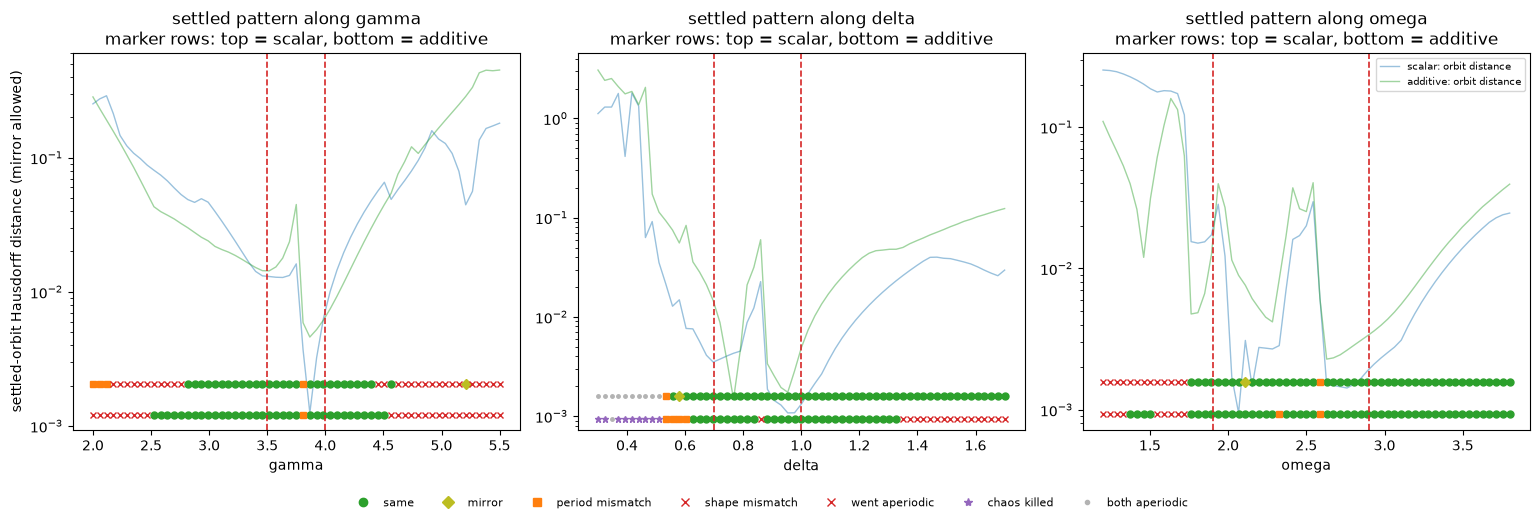

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15.5, 5.2))
for a, (pname, jdx, vals) in zip(ax, RAYS):
    _, j, rows = results[pname]
    for tag, y0, in [('scalar', 1.0), ('additive', 0.0)]:
        vs, ds, ps = rows[tag]
        base = {'scalar': 'tab:blue', 'additive': 'tab:green'}[tag]
        a.semilogy(vals, np.maximum(ds, 1e-4), color=base, lw=1.0,
                   alpha=0.45, label=f'{tag}: orbit distance')
    ymin, ymax = a.get_ylim()
    row_y = {'scalar': ymin * 2.2, 'additive': ymin * 1.3}
    for tag in ('scalar', 'additive'):
        vs, ds, ps = rows[tag]
        for v in COLORS:
            idx = [k for k, vv in enumerate(vs) if vv == v]
            if idx:
                a.plot(vals[idx], [row_y[tag]] * len(idx), MARKS[v],
                       color=COLORS[v], ms=5, ls='none')
    a.axvline(P_LO[j], color='tab:red', lw=1.2, ls='--')
    a.axvline(P_HI[j], color='tab:red', lw=1.2, ls='--')
    a.set_xlabel(pname)
    a.set_title(f'settled pattern along {pname}\n'
                'marker rows: top = scalar, bottom = additive')
    a.set_ylim(ymin, ymax)
a.legend(fontsize=7, loc='upper right')
ax[0].set_ylabel('settled-orbit Hausdorff distance (mirror allowed)')

from matplotlib.lines import Line2D
handles = [Line2D([], [], marker=MARKS[v], color=COLORS[v], ls='none',
                  label=v) for v in COLORS]
fig.legend(handles=handles, loc='lower center', ncol=7, fontsize=8,
           frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

**How to read it:** the faint curves are the distance between the settled orbits
(truth vs model, mirror allowed) — down at $10^{-2\text{--}3}$ the two limit cycles are
visually identical. The marker rows are the verdicts per ray point (top row scalar,
bottom additive). Anything green/olive/grey is a *pattern success*: the model settles
into the exact true pattern, its mirror twin, or correctly stays aperiodic where the
truth is. Orange/red/purple are genuine structural failures — and their locations
(relative to the red training-range lines) say whether structure survives further in
parameter space than pointwise accuracy does.


---

## Scoreboard — Step 9 (big-data run: 128 params × 35 ICs = 8.96M pairs, 60k steps)

| Metric | Scalar | Additive | Better |
|---|---|---|---|
| Parameters | 4,737 | 3,587 | additive |
| Final eval loss (MSE) | 2.28e-9 | 1.50e-9 | additive |
| Unseen params — median rollout err | 1.67e-2 | **1.30e-2** | additive |
| γ-ray median err | 4.5e-2 | **3.6e-2** | additive |
| δ-ray median err | **2.7e-2** | 6.3e-2 | scalar |
| ω-ray median err | 9.4e-3 | 9.4e-3 | tie |
| Settled pattern correct — γ (of 61) | 29 | **34** | additive |
| Settled pattern correct — δ (of 61) | **60** | 31 | scalar |
| Settled pattern correct — ω (of 61) | 47 | **50** | additive |
